# Étape 1 : Exploration & Compréhension des Données

## Objectif
Se familiariser avec la structure et les caractéristiques du dataset H&M.

## À propos du Dataset H&M

### Contexte Business
H&M (Hennes & Mauritz) est un géant suédois de la mode fondé en 1947, leader dans le secteur "fast fashion". Avec plus de 5 000 magasins dans le monde et 120 000 employés, H&M cherche à améliorer son expérience e-commerce post-COVID-19.

### Objectif du Projet
Construire un système de recommandation pour personnaliser l'expérience d'achat en ligne et augmenter les ventes via des recommandations ciblées.

### Source des Données
Ce dataset provient d'une [compétition Kaggle](https://www.kaggle.com/competitions/h-and-m-personalized-fashion-recommendations) sponsorisée par H&M.

### Caractéristiques du Dataset
- **Période couverte** : ~2 ans (septembre 2018 - septembre 2020)
- **Type d'interactions** : **Binaires** (achat/pas d'achat) - pas de ratings explicites
- **Transactions** : Historique d'achats avec timestamps et prix
- **Articles** : ~105K produits (vêtements, accessoires, cosmétiques, chaussures, etc.)
- **Clients** : ~1.4M utilisateurs avec profils démographiques

## ⚠️ Challenge Principal : Interactions Binaires

Contrairement aux datasets classiques (IMDB, Netflix) qui ont des ratings 1-5, ce dataset n'a que des **interactions binaires** :
- **1** : Le client a acheté l'article
- **0** : Le client n'a PAS acheté l'article

**Problème** : Impossible de distinguer entre :
1. Un utilisateur a vu l'article mais ne l'a pas aimé ❌
2. Un utilisateur n'a jamais vu l'article ❓

**Implication** : Nous devons assumer que tous les articles sont "vus" par le client, ce qui rend l'évaluation plus challengeante.

## Questions Clés d'Exploration
- Combien d'utilisateurs et d'items uniques ?
- Quelle est la sparsité du dataset ?
- Comment les interactions sont-elles distribuées ?
- Y a-t-il des duplicates à nettoyer ?
- Y a-t-il des patterns temporels ou saisonniers ?
- Quelles métadonnées sont disponibles pour le Content-Based Filtering ?

## 1. Configuration et Imports

In [1]:
# Imports standards
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Style des visualisations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Imports et configuration terminés")

✅ Imports et configuration terminés


## 2. Chargement des Données

Nous allons charger les trois fichiers CSV du dataset H&M.

In [2]:
# Chemins des fichiers
DATA_PATH = 'data/'

print("📂 Chargement des données...")
print("-" * 50)

# Chargement des transactions
print("Chargement de transactions_train.csv...")
transactions = pd.read_csv(DATA_PATH + 'transactions_train.csv')
print(f"  ✓ {len(transactions):,} transactions chargées")

# Chargement des articles
print("\nChargement de articles.csv...")
articles = pd.read_csv(DATA_PATH + 'articles.csv')
print(f"  ✓ {len(articles):,} articles chargés")

# Chargement des clients
print("\nChargement de customers.csv...")
customers = pd.read_csv(DATA_PATH + 'customers.csv')
print(f"  ✓ {len(customers):,} clients chargés")

print("\n✅ Toutes les données ont été chargées avec succès !")

📂 Chargement des données...
--------------------------------------------------
Chargement de transactions_train.csv...
  ✓ 31,788,324 transactions chargées

Chargement de articles.csv...
  ✓ 105,542 articles chargés

Chargement de customers.csv...
  ✓ 1,371,980 clients chargés

✅ Toutes les données ont été chargées avec succès !


### 2.1 Vérification des Duplicates

D'après l'analyse d'un projet similaire, le dataset H&M contient des transactions en double. Il est crucial de les identifier et de les traiter avant l'analyse.

## 3. Analyse de Base des Datasets

### 3.1 Dataset Transactions

In [3]:
print("=" * 80)
print("TRANSACTIONS DATASET")
print("=" * 80)

print(f"\n📊 Dimensions: {transactions.shape[0]:,} lignes × {transactions.shape[1]} colonnes")
print(f"\n📋 Colonnes: {list(transactions.columns)}")
print(f"\n💾 Mémoire utilisée: {transactions.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n🔍 Aperçu des premières lignes:")
display(transactions.head(10))

print("\n📈 Types de données:")
display(transactions.dtypes)

print("\n📊 Statistiques descriptives:")
display(transactions.describe())

print("\n❓ Valeurs manquantes:")
missing = transactions.isnull().sum()
missing_pct = (missing / len(transactions)) * 100
missing_df = pd.DataFrame({
    'Nombre': missing,
    'Pourcentage': missing_pct
})
display(missing_df[missing_df['Nombre'] > 0])

TRANSACTIONS DATASET

📊 Dimensions: 31,788,324 lignes × 5 colonnes

📋 Colonnes: ['t_dat', 'customer_id', 'article_id', 'price', 'sales_channel_id']

💾 Mémoire utilisée: 6426.93 MB

🔍 Aperçu des premières lignes:


,t_dat,customer_id,article_id,price,sales_channel_id
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,0.050831,2
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,0.030492,2
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,0.015237,2
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,0.016932,2
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,0.016932,2
5,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687001,0.016932,2
6,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221001,0.020322,2
7,2018-09-20,00083cda041544b2fbb0e0d2905ad17da7cf1007526fb4...,688873012,0.030492,1
8,2018-09-20,00083cda041544b2fbb0e0d2905ad17da7cf1007526fb4...,501323011,0.053373,1
9,2018-09-20,00083cda041544b2fbb0e0d2905ad17da7cf1007526fb4...,598859003,0.045746,2



📈 Types de données:


t_dat                object
customer_id          object
article_id            int64
price               float64
sales_channel_id      int64
dtype: object


📊 Statistiques descriptives:


,article_id,price,sales_channel_id
count,3.178832e+07,3.178832e+07,3.178832e+07
mean,6.962272e+08,2.782927e-02,1.704028e+00
std,1.334480e+08,1.918113e-02,4.564786e-01
min,1.087750e+08,1.694915e-05,1.000000e+00
25%,6.328030e+08,1.581356e-02,1.000000e+00
50%,7.145820e+08,2.540678e-02,2.000000e+00
75%,7.865240e+08,3.388136e-02,2.000000e+00
max,9.562170e+08,5.915254e-01,2.000000e+00



❓ Valeurs manquantes:


,Nombre,Pourcentage


### 3.2 Dataset Articles

In [4]:
print("=" * 80)
print("ARTICLES DATASET")
print("=" * 80)

print(f"\n📊 Dimensions: {articles.shape[0]:,} lignes × {articles.shape[1]} colonnes")
print(f"\n📋 Colonnes: {list(articles.columns)}")
print(f"\n💾 Mémoire utilisée: {articles.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n🔍 Aperçu des premières lignes:")
display(articles.head(10))

print("\n📈 Types de données:")
display(articles.dtypes)

print("\n❓ Valeurs manquantes:")
missing = articles.isnull().sum()
missing_pct = (missing / len(articles)) * 100
missing_df = pd.DataFrame({
    'Nombre': missing,
    'Pourcentage': missing_pct
})
display(missing_df[missing_df['Nombre'] > 0])

ARTICLES DATASET

📊 Dimensions: 105,542 lignes × 25 colonnes

📋 Colonnes: ['article_id', 'product_code', 'prod_name', 'product_type_no', 'product_type_name', 'product_group_name', 'graphical_appearance_no', 'graphical_appearance_name', 'colour_group_code', 'colour_group_name', 'perceived_colour_value_id', 'perceived_colour_value_name', 'perceived_colour_master_id', 'perceived_colour_master_name', 'department_no', 'department_name', 'index_code', 'index_name', 'index_group_no', 'index_group_name', 'section_no', 'section_name', 'garment_group_no', 'garment_group_name', 'detail_desc']

💾 Mémoire utilisée: 117.58 MB

🔍 Aperçu des premières lignes:


,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,perceived_colour_value_id,perceived_colour_value_name,perceived_colour_master_id,perceived_colour_master_name,department_no,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,4,Dark,5,Black,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,3,Light,9,White,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,1,Dusty Light,9,White,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,4,Dark,5,Black,1339,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,3,Light,9,White,1339,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
5,110065011,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,12,Light Beige,1,Dusty Light,11,Beige,1339,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
6,111565001,111565,20 den 1p Stockings,304,Underwear Tights,Socks & Tights,1010016,Solid,9,Black,4,Dark,5,Black,3608,Tights basic,B,Lingeries/Tights,1,Ladieswear,62,"Womens Nightwear, Socks & Tigh",1021,Socks and Tights,"Semi shiny nylon stockings with a wide, reinfo..."
7,111565003,111565,20 den 1p Stockings,302,Socks,Socks & Tights,1010016,Solid,13,Beige,2,Medium Dusty,11,Beige,3608,Tights basic,B,Lingeries/Tights,1,Ladieswear,62,"Womens Nightwear, Socks & Tigh",1021,Socks and Tights,"Semi shiny nylon stockings with a wide, reinfo..."
8,111586001,111586,Shape Up 30 den 1p Tights,273,Leggings/Tights,Garment Lower body,1010016,Solid,9,Black,4,Dark,5,Black,3608,Tights basic,B,Lingeries/Tights,1,Ladieswear,62,"Womens Nightwear, Socks & Tigh",1021,Socks and Tights,Tights with built-in support to lift the botto...
9,111593001,111593,Support 40 den 1p Tights,304,Underwear Tights,Socks & Tights,1010016,Solid,9,Black,4,Dark,5,Black,3608,Tights basic,B,Lingeries/Tights,1,Ladieswear,62,"Womens Nightwear, Socks & Tigh",1021,Socks and Tights,"Semi shiny tights that shape the tummy, thighs..."



📈 Types de données:


article_id                       int64
product_code                     int64
prod_name                       object
product_type_no                  int64
product_type_name               object
product_group_name              object
graphical_appearance_no          int64
graphical_appearance_name       object
colour_group_code                int64
colour_group_name               object
perceived_colour_value_id        int64
perceived_colour_value_name     object
perceived_colour_master_id       int64
perceived_colour_master_name    object
department_no                    int64
department_name                 object
index_code                      object
index_name                      object
index_group_no                   int64
index_group_name                object
section_no                       int64
section_name                    object
garment_group_no                 int64
garment_group_name              object
detail_desc                     object
dtype: object


❓ Valeurs manquantes:


,Nombre,Pourcentage
detail_desc,416,0.394156


### 3.3 Dataset Customers

In [5]:
print("=" * 80)
print("CUSTOMERS DATASET")
print("=" * 80)

print(f"\n📊 Dimensions: {customers.shape[0]:,} lignes × {customers.shape[1]} colonnes")
print(f"\n📋 Colonnes: {list(customers.columns)}")
print(f"\n💾 Mémoire utilisée: {customers.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n🔍 Aperçu des premières lignes:")
display(customers.head(10))

print("\n📈 Types de données:")
display(customers.dtypes)

print("\n❓ Valeurs manquantes:")
missing = customers.isnull().sum()
missing_pct = (missing / len(customers)) * 100
missing_df = pd.DataFrame({
    'Nombre': missing,
    'Pourcentage': missing_pct
})
display(missing_df[missing_df['Nombre'] > 0])

CUSTOMERS DATASET

📊 Dimensions: 1,371,980 lignes × 7 colonnes

📋 Colonnes: ['customer_id', 'FN', 'Active', 'club_member_status', 'fashion_news_frequency', 'age', 'postal_code']

💾 Mémoire utilisée: 512.30 MB

🔍 Aperçu des premières lignes:


,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,NaN,NaN,ACTIVE,NONE,49.0,52043ee2162cf5aa7ee79974281641c6f11a68d276429a...
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,NaN,NaN,ACTIVE,NONE,25.0,2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,NaN,NaN,ACTIVE,NONE,24.0,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,NaN,NaN,ACTIVE,NONE,54.0,5d36574f52495e81f019b680c843c443bd343d5ca5b1c2...
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1.0,1.0,ACTIVE,Regularly,52.0,25fa5ddee9aac01b35208d01736e57942317d756b32ddd...
5,000064249685c11552da43ef22a5030f35a147f723d5b0...,NaN,NaN,NaN,NaN,NaN,2c29ae653a9282cce4151bd87643c907644e09541abc28...
6,0000757967448a6cb83efb3ea7a3fb9d418ac7adf2379d...,NaN,NaN,ACTIVE,NONE,20.0,fe7b8e2b3fafb89ca90db17ffeeae0fd29b795d803f749...
7,00007d2de826758b65a93dd24ce629ed66842531df6699...,1.0,1.0,ACTIVE,Regularly,32.0,8d6f45050876d059c830a0fe63f1a4c022de279bb68ce3...
8,00007e8d4e54114b5b2a9b51586325a8d0fa74ea23ef77...,NaN,NaN,ACTIVE,NONE,20.0,2c29ae653a9282cce4151bd87643c907644e09541abc28...
9,00008469a21b50b3d147c97135e25b4201a8c58997f787...,NaN,NaN,ACTIVE,NONE,20.0,2c29ae653a9282cce4151bd87643c907644e09541abc28...



📈 Types de données:


customer_id                object
FN                        float64
Active                    float64
club_member_status         object
fashion_news_frequency     object
age                       float64
postal_code                object
dtype: object


❓ Valeurs manquantes:


,Nombre,Pourcentage
FN,895050,65.237831
Active,907576,66.150819
club_member_status,6062,0.441843
fashion_news_frequency,16011,1.167000
age,15861,1.156066


## 4. Analyse de la Sparsité

La sparsité est un indicateur clé pour les systèmes de recommandation. Elle mesure le pourcentage d'interactions possibles qui n'ont pas eu lieu.

ANALYSE DE SPARSITÉ

👥 Nombre d'utilisateurs uniques: 1,362,281
📦 Nombre d'items uniques: 104,547
🔄 Nombre d'interactions: 31,788,324

📊 Interactions possibles: 142,422,391,707
📊 Interactions réelles: 31,788,324

⚠️ Sparsité: 99.98%
✓ Densité: 0.0223%


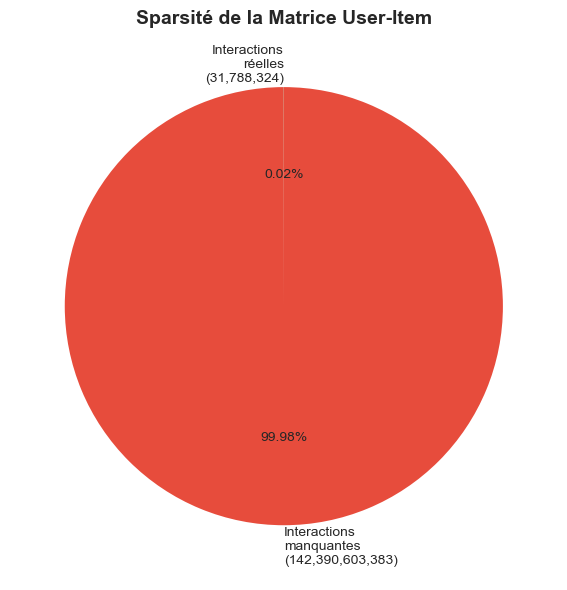

In [6]:
print("=" * 80)
print("ANALYSE DE SPARSITÉ")
print("=" * 80)

# Calculer les statistiques de base
n_users = transactions['customer_id'].nunique()
n_items = transactions['article_id'].nunique()
n_interactions = len(transactions)

# Calculer la sparsité
possible_interactions = n_users * n_items
sparsity = 1 - (n_interactions / possible_interactions)

print(f"\n👥 Nombre d'utilisateurs uniques: {n_users:,}")
print(f"📦 Nombre d'items uniques: {n_items:,}")
print(f"🔄 Nombre d'interactions: {n_interactions:,}")
print(f"\n📊 Interactions possibles: {possible_interactions:,}")
print(f"📊 Interactions réelles: {n_interactions:,}")
print(f"\n⚠️ Sparsité: {sparsity:.2%}")
print(f"✓ Densité: {(1-sparsity):.4%}")

# Visualisation
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

values = [n_interactions, possible_interactions - n_interactions]
labels = [f'Interactions\nréelles\n({n_interactions:,})', 
          f'Interactions\nmanquantes\n({possible_interactions - n_interactions:,.0f})']
colors = ['#2ecc71', '#e74c3c']

ax.pie(values, labels=labels, autopct='%1.2f%%', colors=colors, startangle=90)
ax.set_title('Sparsité de la Matrice User-Item', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


<b>💡 Interprétation:</b><br>
Le dataset est extrêmement sparse à 99.98%, ce qui est typique pour les systèmes de recommandation. Chaque utilisateur n'interagit qu'avec une infime fraction du catalogue disponible.

## 5. Distribution des Interactions

### 5.1 Distribution par Utilisateur

DISTRIBUTION DES INTERACTIONS PAR UTILISATEUR

📊 Statistiques:
   Moyenne: 23.33 interactions/user
   Médiane: 9 interactions/user
   Écart-type: 39.24
   Min: 1
   Max: 1895

📈 Quartiles:
count    1.362281e+06
mean     2.333463e+01
std      3.924225e+01
min      1.000000e+00
25%      3.000000e+00
50%      9.000000e+00
75%      2.700000e+01
max      1.895000e+03
dtype: float64


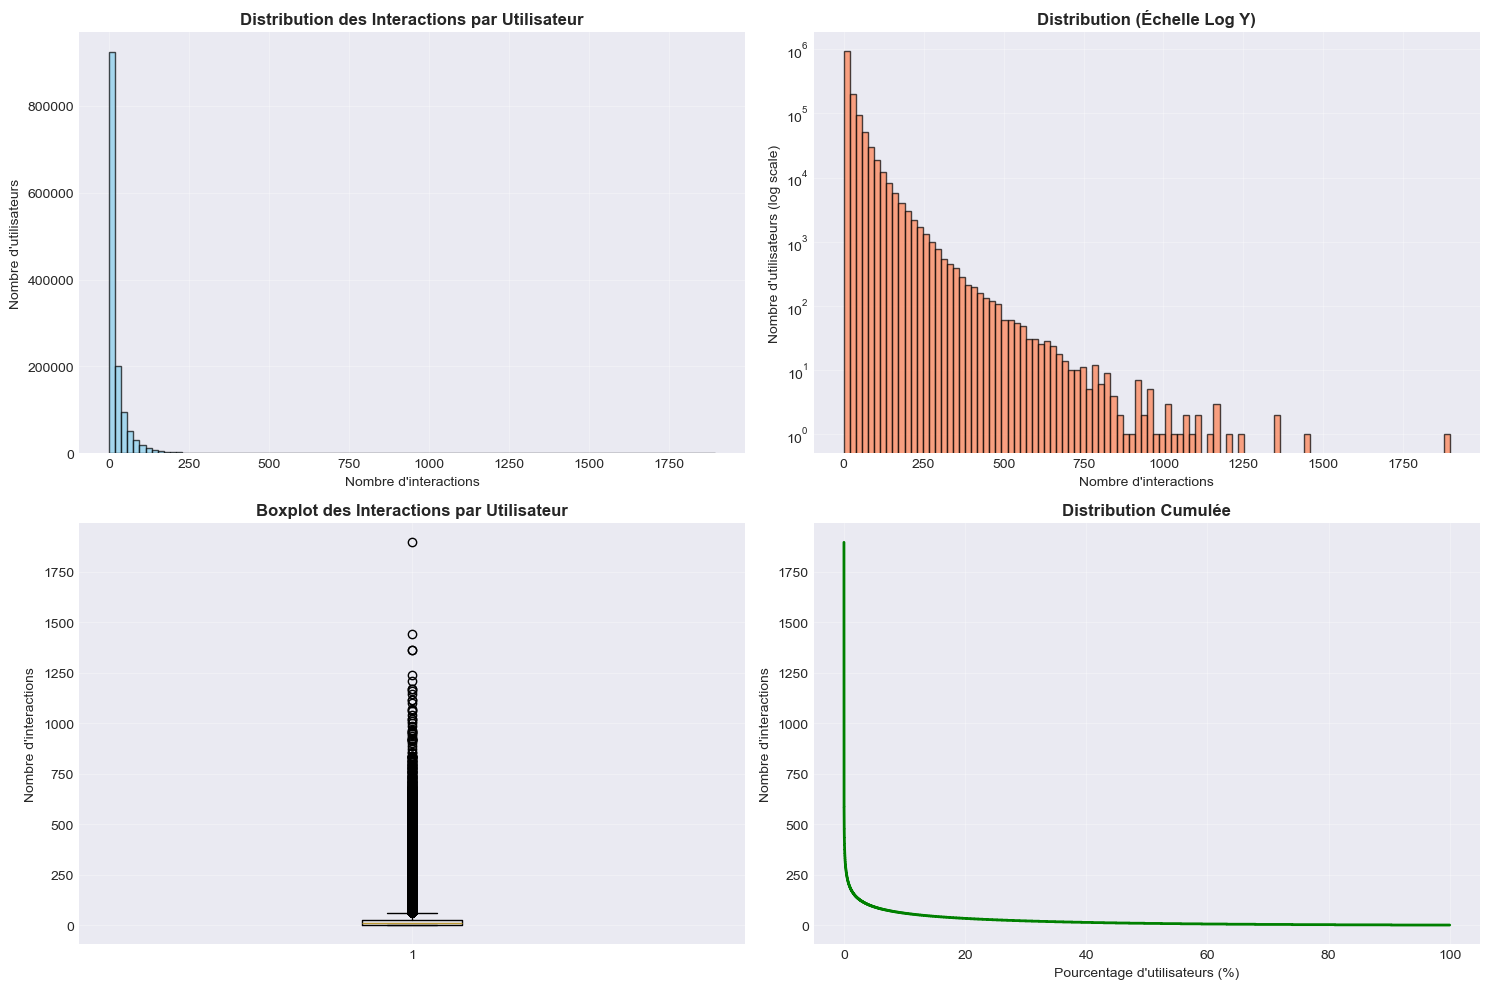


👑 Top 10 Power Users:
    1. User be1981ab818cf4ef6765b2ecaea7a2cbf14ccd6e8a7ee985513d9e8e53c6d91b: 1,895 interactions
    2. User b4db5e5259234574edfff958e170fe3a5e13b6f146752ca066abca3c156acc71: 1,441 interactions
    3. User 49beaacac0c7801c2ce2d189efe525fe80b5d37e46ed05b50a4cd88e34d0748f: 1,364 interactions
    4. User a65f77281a528bf5c1e9f270141d601d116e1df33bf9df512f495ee06647a9cc: 1,361 interactions
    5. User cd04ec2726dd58a8c753e0d6423e57716fd9ebcf2f14ed6012e7e5bea016b4d6: 1,237 interactions
    6. User 55d15396193dfd45836af3a6269a079efea339e875eff42cc0c228b002548a9d: 1,208 interactions
    7. User c140410d72a41ee5e2e3ba3d7f5a860f337f1b5e41c27cf9bda5517c8774f8fa: 1,170 interactions
    8. User 8df45859ccd71ef1e48e2ee9d1c65d5728c31c46ae957d659fa4e5c3af6cc076: 1,169 interactions
    9. User 03d0011487606c37c1b1ed147fc72f285a50c05f00b9712e0fc3da400c864296: 1,157 interactions
   10. User 6cc121e5cc202d2bf344ffe795002bdbf87178054bcda2e57161f0ef810a4b55: 1,143 interactions


In [7]:
print("=" * 80)
print("DISTRIBUTION DES INTERACTIONS PAR UTILISATEUR")
print("=" * 80)

# Calculer les interactions par utilisateur
user_interactions = transactions.groupby('customer_id').size()

print(f"\n📊 Statistiques:")
print(f"   Moyenne: {user_interactions.mean():.2f} interactions/user")
print(f"   Médiane: {user_interactions.median():.0f} interactions/user")
print(f"   Écart-type: {user_interactions.std():.2f}")
print(f"   Min: {user_interactions.min():.0f}")
print(f"   Max: {user_interactions.max():.0f}")
print(f"\n📈 Quartiles:")
print(user_interactions.describe())

# Visualisations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogramme
axes[0, 0].hist(user_interactions, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Nombre d\'interactions')
axes[0, 0].set_ylabel('Nombre d\'utilisateurs')
axes[0, 0].set_title('Distribution des Interactions par Utilisateur', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Histogramme (échelle log)
axes[0, 1].hist(user_interactions, bins=100, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Nombre d\'interactions')
axes[0, 1].set_ylabel('Nombre d\'utilisateurs (log scale)')
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Distribution (Échelle Log Y)', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Boxplot
axes[1, 0].boxplot(user_interactions, vert=True)
axes[1, 0].set_ylabel('Nombre d\'interactions')
axes[1, 0].set_title('Boxplot des Interactions par Utilisateur', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Distribution cumulée
sorted_interactions = np.sort(user_interactions)[::-1]
cumulative_pct = np.arange(1, len(sorted_interactions) + 1) / len(sorted_interactions) * 100
axes[1, 1].plot(cumulative_pct, sorted_interactions, color='green', linewidth=2)
axes[1, 1].set_xlabel('Pourcentage d\'utilisateurs (%)')
axes[1, 1].set_ylabel('Nombre d\'interactions')
axes[1, 1].set_title('Distribution Cumulée', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Identifier les power users
print("\n👑 Top 10 Power Users:")
top_users = user_interactions.nlargest(10)
for i, (user_id, count) in enumerate(top_users.items(), 1):
    print(f"   {i:2d}. User {user_id}: {count:,} interactions")

### 5.2 Distribution par Article

DISTRIBUTION DES INTERACTIONS PAR ARTICLE

📊 Statistiques:
   Moyenne: 304.06 interactions/item
   Médiane: 65 interactions/item
   Écart-type: 791.27
   Min: 1
   Max: 50287

📈 Quartiles:
count    104547.000000
mean        304.057735
std         791.266060
min           1.000000
25%          14.000000
50%          65.000000
75%         286.000000
max       50287.000000
dtype: float64


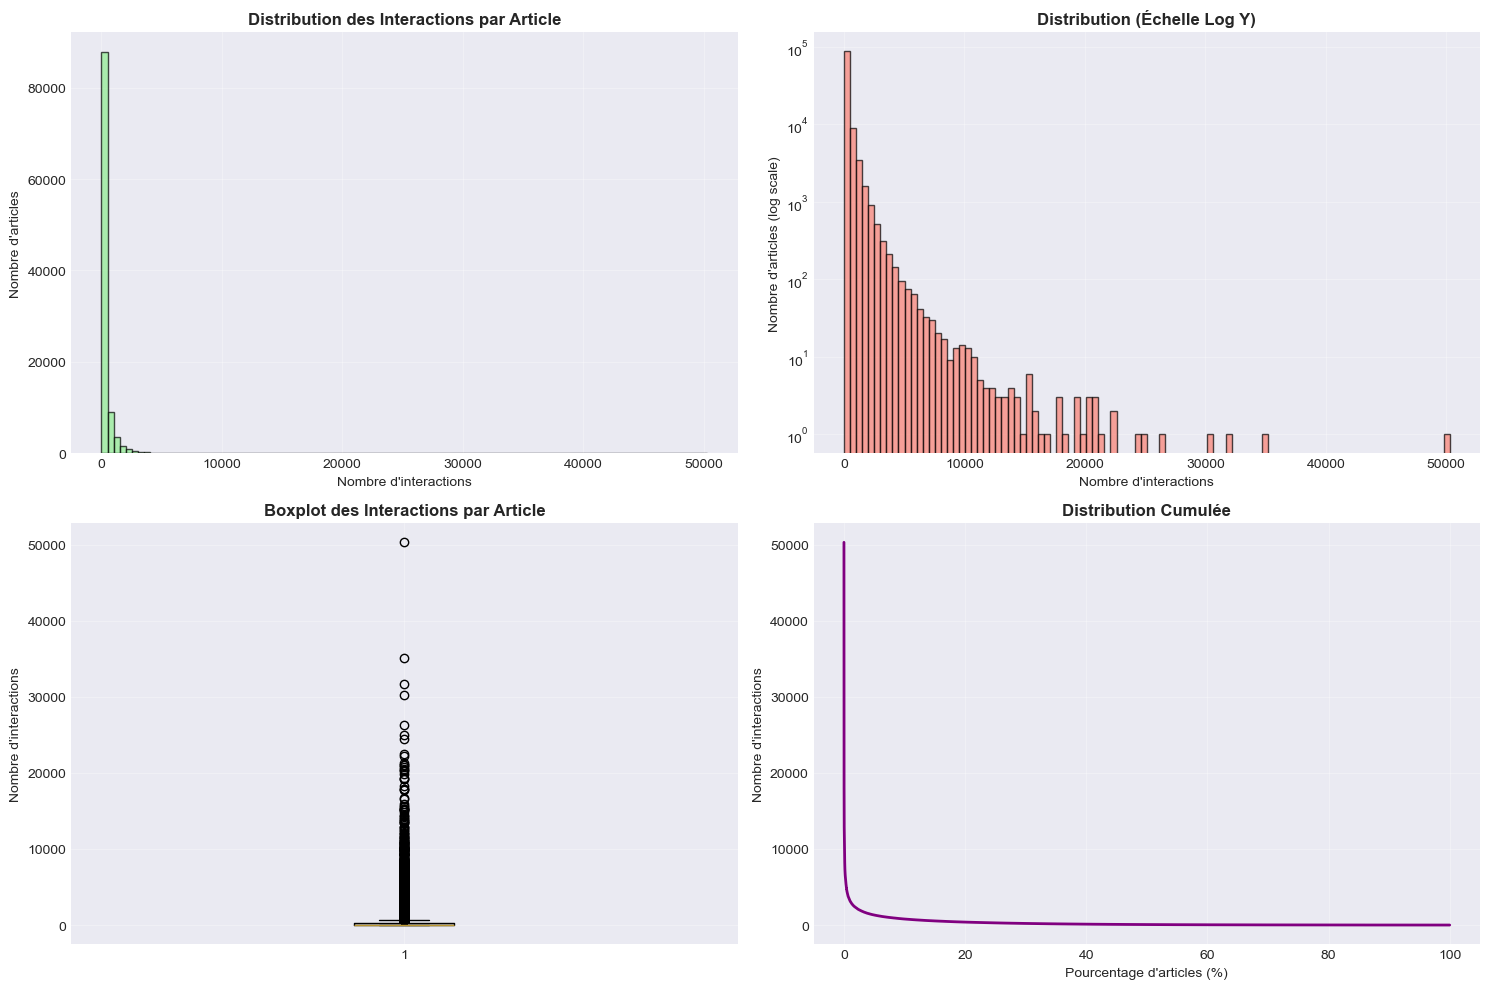


⭐ Top 10 Articles Populaires:
    1. Article 706016001 - Jade HW Skinny Denim TRS: 50,287 interactions
    2. Article 706016002 - Jade HW Skinny Denim TRS: 35,043 interactions
    3. Article 372860001 - 7p Basic Shaftless: 31,718 interactions
    4. Article 610776002 - Tilly (1): 30,199 interactions
    5. Article 759871002 - Tilda tank: 26,329 interactions
    6. Article 464297007 - Greta Thong Mynta Low 3p: 25,025 interactions
    7. Article 372860002 - 7p Basic Shaftless: 24,458 interactions
    8. Article 610776001 - Tilly (1): 22,451 interactions
    9. Article 399223001 - Curvy Jeggings HW Ankle: 22,236 interactions
   10. Article 706016003 - Jade HW Skinny Denim TRS: 21,241 interactions


In [8]:
print("=" * 80)
print("DISTRIBUTION DES INTERACTIONS PAR ARTICLE")
print("=" * 80)

# Calculer les interactions par article
item_interactions = transactions.groupby('article_id').size()

print(f"\n📊 Statistiques:")
print(f"   Moyenne: {item_interactions.mean():.2f} interactions/item")
print(f"   Médiane: {item_interactions.median():.0f} interactions/item")
print(f"   Écart-type: {item_interactions.std():.2f}")
print(f"   Min: {item_interactions.min():.0f}")
print(f"   Max: {item_interactions.max():.0f}")
print(f"\n📈 Quartiles:")
print(item_interactions.describe())

# Visualisations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogramme
axes[0, 0].hist(item_interactions, bins=100, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Nombre d\'interactions')
axes[0, 0].set_ylabel('Nombre d\'articles')
axes[0, 0].set_title('Distribution des Interactions par Article', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Histogramme (échelle log)
axes[0, 1].hist(item_interactions, bins=100, color='salmon', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Nombre d\'interactions')
axes[0, 1].set_ylabel('Nombre d\'articles (log scale)')
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Distribution (Échelle Log Y)', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Boxplot
axes[1, 0].boxplot(item_interactions, vert=True)
axes[1, 0].set_ylabel('Nombre d\'interactions')
axes[1, 0].set_title('Boxplot des Interactions par Article', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Distribution cumulée
sorted_interactions = np.sort(item_interactions)[::-1]
cumulative_pct = np.arange(1, len(sorted_interactions) + 1) / len(sorted_interactions) * 100
axes[1, 1].plot(cumulative_pct, sorted_interactions, color='purple', linewidth=2)
axes[1, 1].set_xlabel('Pourcentage d\'articles (%)')
axes[1, 1].set_ylabel('Nombre d\'interactions')
axes[1, 1].set_title('Distribution Cumulée', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Identifier les blockbusters
print("\n⭐ Top 10 Articles Populaires:")
top_items = item_interactions.nlargest(10)
for i, (item_id, count) in enumerate(top_items.items(), 1):
    # Récupérer le nom de l'article si disponible
    item_name = articles[articles['article_id'] == item_id]['prod_name'].values
    name = item_name[0] if len(item_name) > 0 else 'N/A'
    print(f"   {i:2d}. Article {item_id} - {name}: {count:,} interactions")

## 6. Analyse de la Longue Traîne (Règle 80/20)

La règle 80/20 (ou principe de Pareto) suggère que 80% des effets proviennent de 20% des causes. Dans les systèmes de recommandation, cela se traduit souvent par le fait qu'une petite fraction d'utilisateurs ou d'items génère la majorité des interactions.

ANALYSE DE LA LONGUE TRAÎNE

👥 UTILISATEURS:
--------------------------------------------------
   30.8% des utilisateurs (419,587) génèrent 80% des interactions
   Les 69.2% restants génèrent 20% des interactions

📦 ARTICLES:
--------------------------------------------------
   20.7% des articles (21,660) génèrent 80% des interactions
   Les 79.3% restants génèrent 20% des interactions


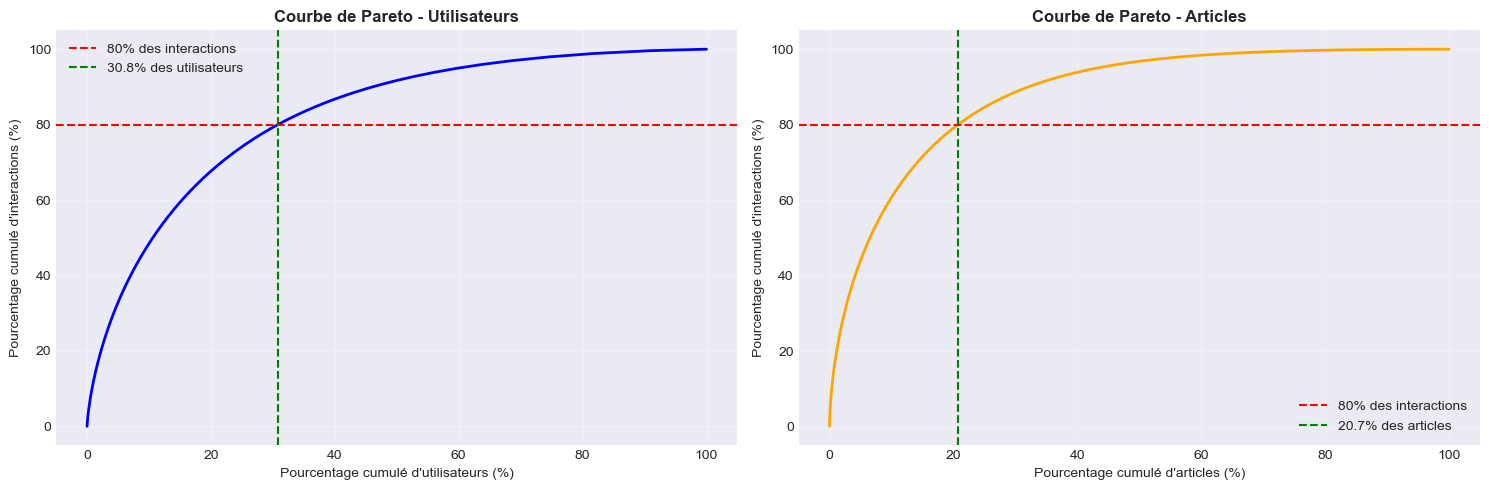


💡 Implications pour le système de recommandation:
   • Une petite fraction d'utilisateurs/items est très active
   • La majorité du catalogue est peu populaire (longue traîne)
   • Besoin de stratégies pour recommander aussi les items de la longue traîne
   • Les modèles hybrides avec features peuvent aider pour le cold-start


In [9]:
print("=" * 80)
print("ANALYSE DE LA LONGUE TRAÎNE")
print("=" * 80)

# Analyse pour les utilisateurs
print("\n👥 UTILISATEURS:")
print("-" * 50)

sorted_user_interactions = user_interactions.sort_values(ascending=False)
cumsum_users = sorted_user_interactions.cumsum()
total_interactions = cumsum_users.iloc[-1]

# Trouver combien d'utilisateurs représentent 80% des interactions
pct_80_idx = (cumsum_users >= 0.8 * total_interactions).idxmax()
n_users_80pct = list(cumsum_users.index).index(pct_80_idx) + 1
pct_users_80 = (n_users_80pct / len(sorted_user_interactions)) * 100

print(f"   {pct_users_80:.1f}% des utilisateurs ({n_users_80pct:,}) génèrent 80% des interactions")
print(f"   Les {100-pct_users_80:.1f}% restants génèrent 20% des interactions")

# Analyse pour les articles
print("\n📦 ARTICLES:")
print("-" * 50)

sorted_item_interactions = item_interactions.sort_values(ascending=False)
cumsum_items = sorted_item_interactions.cumsum()

# Trouver combien d'articles représentent 80% des interactions
pct_80_idx = (cumsum_items >= 0.8 * total_interactions).idxmax()
n_items_80pct = list(cumsum_items.index).index(pct_80_idx) + 1
pct_items_80 = (n_items_80pct / len(sorted_item_interactions)) * 100

print(f"   {pct_items_80:.1f}% des articles ({n_items_80pct:,}) génèrent 80% des interactions")
print(f"   Les {100-pct_items_80:.1f}% restants génèrent 20% des interactions")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Courbe de Pareto pour les utilisateurs
cumsum_pct_users = (cumsum_users / total_interactions * 100).values
user_pct = np.arange(1, len(cumsum_pct_users) + 1) / len(cumsum_pct_users) * 100

axes[0].plot(user_pct, cumsum_pct_users, linewidth=2, color='blue')
axes[0].axhline(y=80, color='red', linestyle='--', label='80% des interactions')
axes[0].axvline(x=pct_users_80, color='green', linestyle='--', 
                label=f'{pct_users_80:.1f}% des utilisateurs')
axes[0].set_xlabel('Pourcentage cumulé d\'utilisateurs (%)')
axes[0].set_ylabel('Pourcentage cumulé d\'interactions (%)')
axes[0].set_title('Courbe de Pareto - Utilisateurs', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Courbe de Pareto pour les articles
cumsum_pct_items = (cumsum_items / total_interactions * 100).values
item_pct = np.arange(1, len(cumsum_pct_items) + 1) / len(cumsum_pct_items) * 100

axes[1].plot(item_pct, cumsum_pct_items, linewidth=2, color='orange')
axes[1].axhline(y=80, color='red', linestyle='--', label='80% des interactions')
axes[1].axvline(x=pct_items_80, color='green', linestyle='--', 
                label=f'{pct_items_80:.1f}% des articles')
axes[1].set_xlabel('Pourcentage cumulé d\'articles (%)')
axes[1].set_ylabel('Pourcentage cumulé d\'interactions (%)')
axes[1].set_title('Courbe de Pareto - Articles', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Implications pour le système de recommandation:")
print(f"   • Une petite fraction d'utilisateurs/items est très active")
print(f"   • La majorité du catalogue est peu populaire (longue traîne)")
print(f"   • Besoin de stratégies pour recommander aussi les items de la longue traîne")
print(f"   • Les modèles hybrides avec features peuvent aider pour le cold-start")

## 7. Analyse Temporelle

### 7.1 Conversion de la colonne date

In [10]:
# Convertir la colonne t_dat en datetime
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])

# Extraire des features temporelles
transactions['year'] = transactions['t_dat'].dt.year
transactions['month'] = transactions['t_dat'].dt.month
transactions['day'] = transactions['t_dat'].dt.day
transactions['dayofweek'] = transactions['t_dat'].dt.dayofweek
transactions['week'] = transactions['t_dat'].dt.isocalendar().week

print("✅ Colonne date convertie et features temporelles extraites")

✅ Colonne date convertie et features temporelles extraites


### 7.2 Période couverte par les données

In [11]:
print("=" * 80)
print("ANALYSE TEMPORELLE")
print("=" * 80)

min_date = transactions['t_dat'].min()
max_date = transactions['t_dat'].max()
duration = (max_date - min_date).days

print(f"\n📅 Période couverte:")
print(f"   Date de début: {min_date.strftime('%Y-%m-%d')}")
print(f"   Date de fin: {max_date.strftime('%Y-%m-%d')}")
print(f"   Durée: {duration} jours ({duration/365.25:.1f} années)")

print(f"\n📊 Distribution par année:")
year_counts = transactions['year'].value_counts().sort_index()
for year, count in year_counts.items():
    print(f"   {year}: {count:,} transactions ({count/len(transactions)*100:.1f}%)")

ANALYSE TEMPORELLE

📅 Période couverte:
   Date de début: 2018-09-20
   Date de fin: 2020-09-22
   Durée: 733 jours (2.0 années)

📊 Distribution par année:
   2018: 4,411,262 transactions (13.9%)
   2019: 16,396,930 transactions (51.6%)
   2020: 10,980,132 transactions (34.5%)


### 7.3 Évolution temporelle des interactions

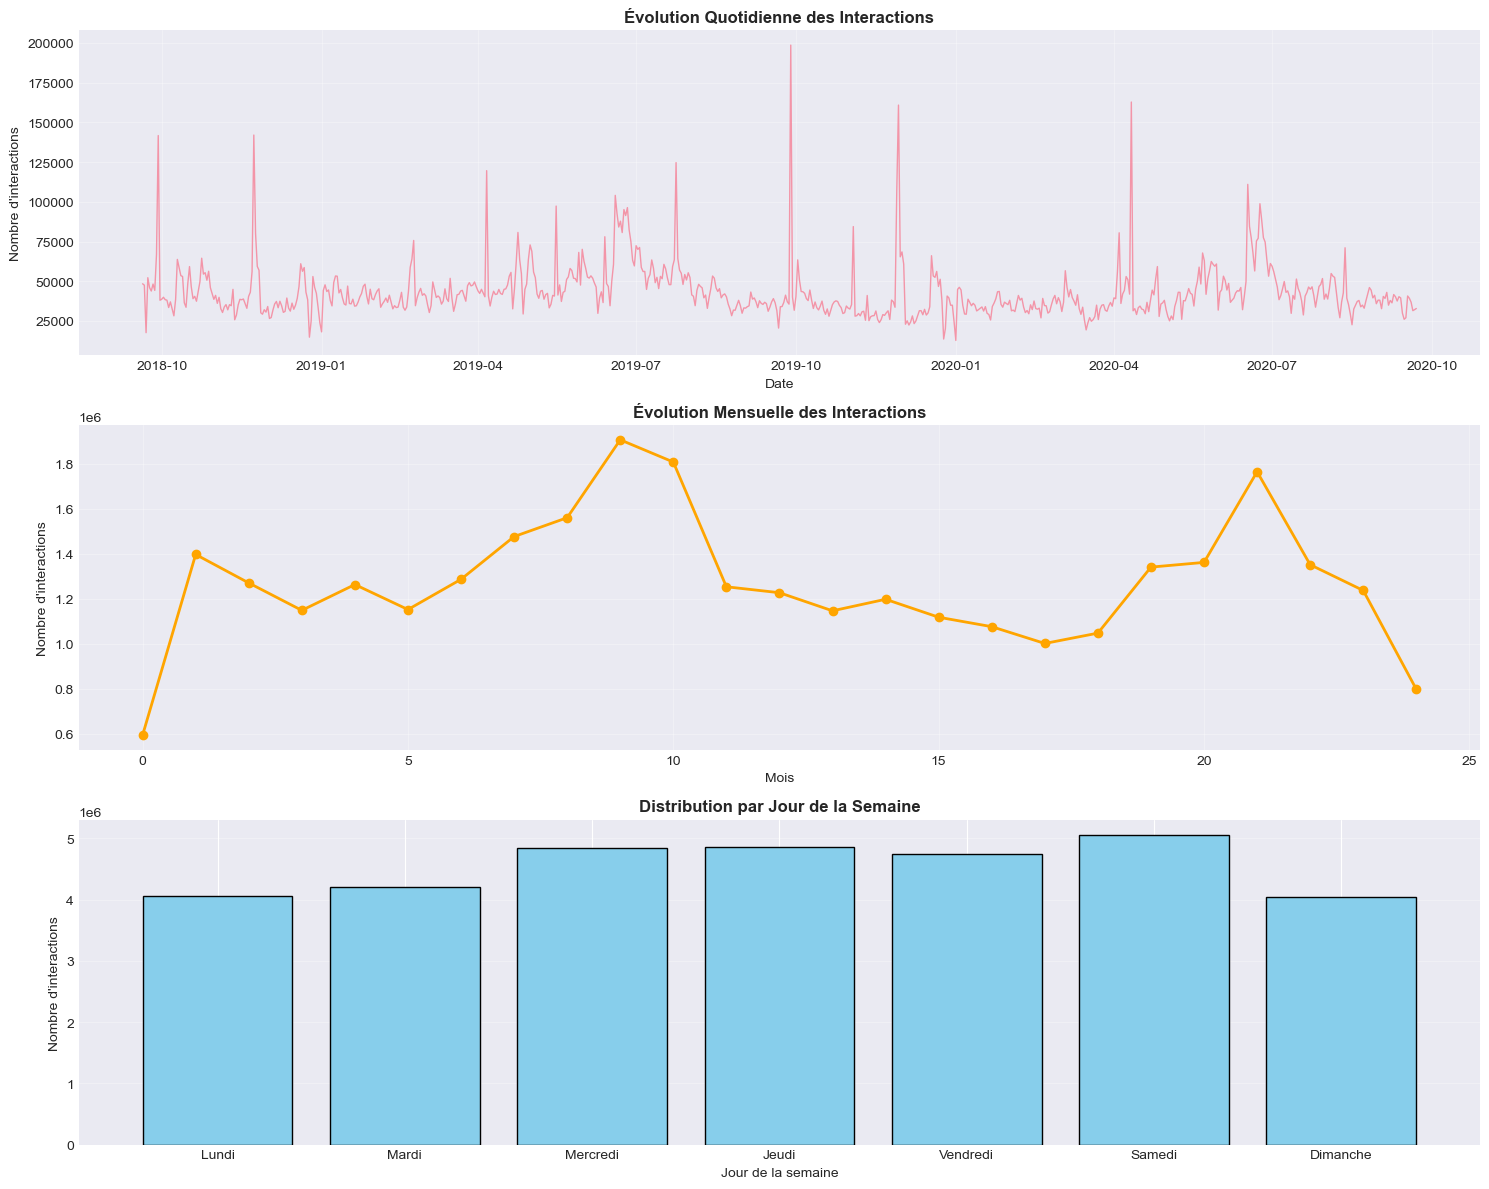


📈 Statistiques par jour de la semaine:
   Lundi     : 4,054,054 (12.8%)
   Mardi     : 4,198,630 (13.2%)
   Mercredi  : 4,842,821 (15.2%)
   Jeudi     : 4,860,595 (15.3%)
   Vendredi  : 4,749,132 (14.9%)
   Samedi    : 5,049,500 (15.9%)
   Dimanche  : 4,033,592 (12.7%)


In [12]:
# Grouper par date
daily_interactions = transactions.groupby('t_dat').size()

# Visualisations
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Évolution quotidienne
axes[0].plot(daily_interactions.index, daily_interactions.values, linewidth=1, alpha=0.7)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Nombre d\'interactions')
axes[0].set_title('Évolution Quotidienne des Interactions', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Par mois
monthly_interactions = transactions.groupby(['year', 'month']).size()
axes[1].plot(range(len(monthly_interactions)), monthly_interactions.values, 
             linewidth=2, marker='o', color='orange')
axes[1].set_xlabel('Mois')
axes[1].set_ylabel('Nombre d\'interactions')
axes[1].set_title('Évolution Mensuelle des Interactions', fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Par jour de la semaine
dow_interactions = transactions.groupby('dayofweek').size()
dow_names = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']
axes[2].bar(dow_names, dow_interactions.values, color='skyblue', edgecolor='black')
axes[2].set_xlabel('Jour de la semaine')
axes[2].set_ylabel('Nombre d\'interactions')
axes[2].set_title('Distribution par Jour de la Semaine', fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n📈 Statistiques par jour de la semaine:")
for i, day in enumerate(dow_names):
    count = dow_interactions.iloc[i]
    pct = count / len(transactions) * 100
    print(f"   {day:10s}: {count:,} ({pct:.1f}%)")

### 7.4 Patterns saisonniers

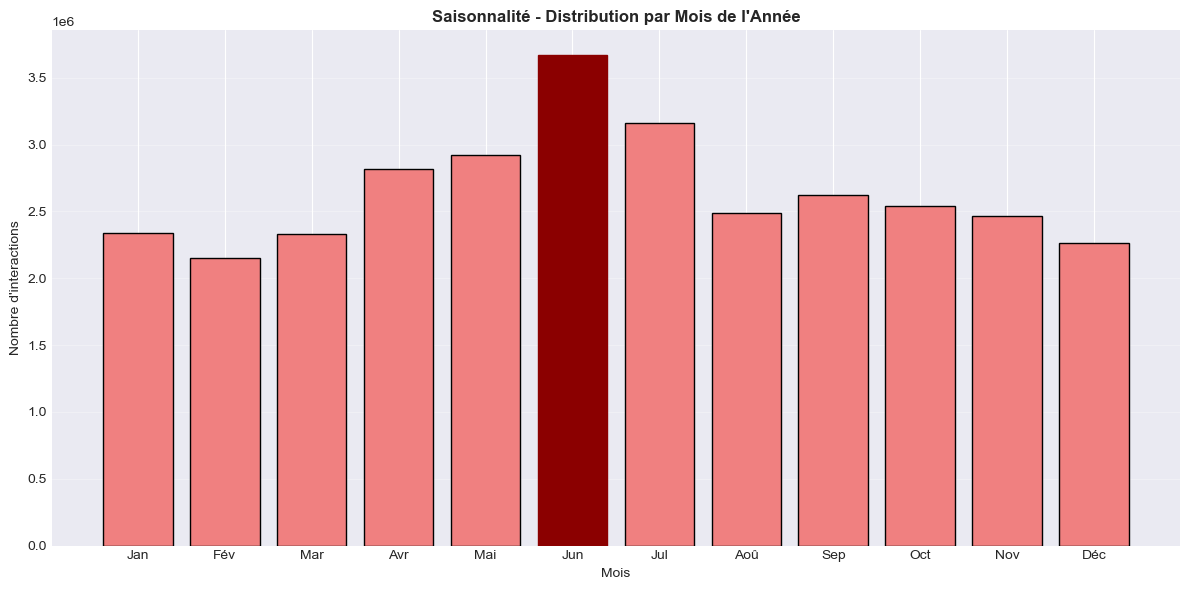


📊 Top 3 mois les plus actifs:
   1. Jun: 3,670,709 interactions
   2. Jul: 3,158,996 interactions
   3. Mai: 2,922,134 interactions

💡 Observations:
   • Y a-t-il des pics pendant les fêtes ou soldes ?
   • Les patterns saisonniers peuvent-ils améliorer les recommandations ?


In [13]:
# Analyser par mois de l'année (tous les ans confondus)
month_interactions = transactions.groupby('month').size()
month_names = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun', 
               'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(month_names, month_interactions.values, color='lightcoral', edgecolor='black')

# Colorer le mois avec le plus d'interactions
max_month_idx = month_interactions.values.argmax()
bars[max_month_idx].set_color('darkred')

ax.set_xlabel('Mois')
ax.set_ylabel('Nombre d\'interactions')
ax.set_title('Saisonnalité - Distribution par Mois de l\'Année', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n📊 Top 3 mois les plus actifs:")
top_months = month_interactions.nlargest(3)
for i, (month, count) in enumerate(top_months.items(), 1):
    print(f"   {i}. {month_names[month-1]}: {count:,} interactions")

print("\n💡 Observations:")
print(f"   • Y a-t-il des pics pendant les fêtes ou soldes ?")
print(f"   • Les patterns saisonniers peuvent-ils améliorer les recommandations ?")

## 8. Exploration des Métadonnées

### 8.1 Métadonnées des Articles

In [14]:
print("=" * 80)
print("EXPLORATION DES MÉTADONNÉES - ARTICLES")
print("=" * 80)

print(f"\n📋 Colonnes disponibles ({len(articles.columns)}):")
for col in articles.columns:
    print(f"   • {col}")

# Analyser les colonnes catégorielles importantes
categorical_cols = ['product_type_name', 'product_group_name', 'colour_group_name', 
                   'department_name', 'index_group_name', 'section_name']

print(f"\n📊 Cardinalité des features catégorielles:")
for col in categorical_cols:
    if col in articles.columns:
        n_unique = articles[col].nunique()
        print(f"   {col:25s}: {n_unique:4d} valeurs uniques")

# Top catégories
print("\n🏆 Top 10 Types de Produits:")
top_types = articles['product_type_name'].value_counts().head(10)
for i, (ptype, count) in enumerate(top_types.items(), 1):
    print(f"   {i:2d}. {ptype:30s}: {count:,}")

print("\n🎨 Top 10 Couleurs:")
top_colors = articles['colour_group_name'].value_counts().head(10)
for i, (color, count) in enumerate(top_colors.items(), 1):
    print(f"   {i:2d}. {color:20s}: {count:,}")

print("\n🏬 Distribution par Département:")
dept_counts = articles['department_name'].value_counts()
for dept, count in dept_counts.items():
    pct = count / len(articles) * 100
    print(f"   {dept:30s}: {count:,} ({pct:.1f}%)")

EXPLORATION DES MÉTADONNÉES - ARTICLES

📋 Colonnes disponibles (25):
   • article_id
   • product_code
   • prod_name
   • product_type_no
   • product_type_name
   • product_group_name
   • graphical_appearance_no
   • graphical_appearance_name
   • colour_group_code
   • colour_group_name
   • perceived_colour_value_id
   • perceived_colour_value_name
   • perceived_colour_master_id
   • perceived_colour_master_name
   • department_no
   • department_name
   • index_code
   • index_name
   • index_group_no
   • index_group_name
   • section_no
   • section_name
   • garment_group_no
   • garment_group_name
   • detail_desc

📊 Cardinalité des features catégorielles:
   product_type_name        :  131 valeurs uniques
   product_group_name       :   19 valeurs uniques
   colour_group_name        :   50 valeurs uniques
   department_name          :  250 valeurs uniques
   index_group_name         :    5 valeurs uniques
   section_name             :   56 valeurs uniques

🏆 Top 10 Types de

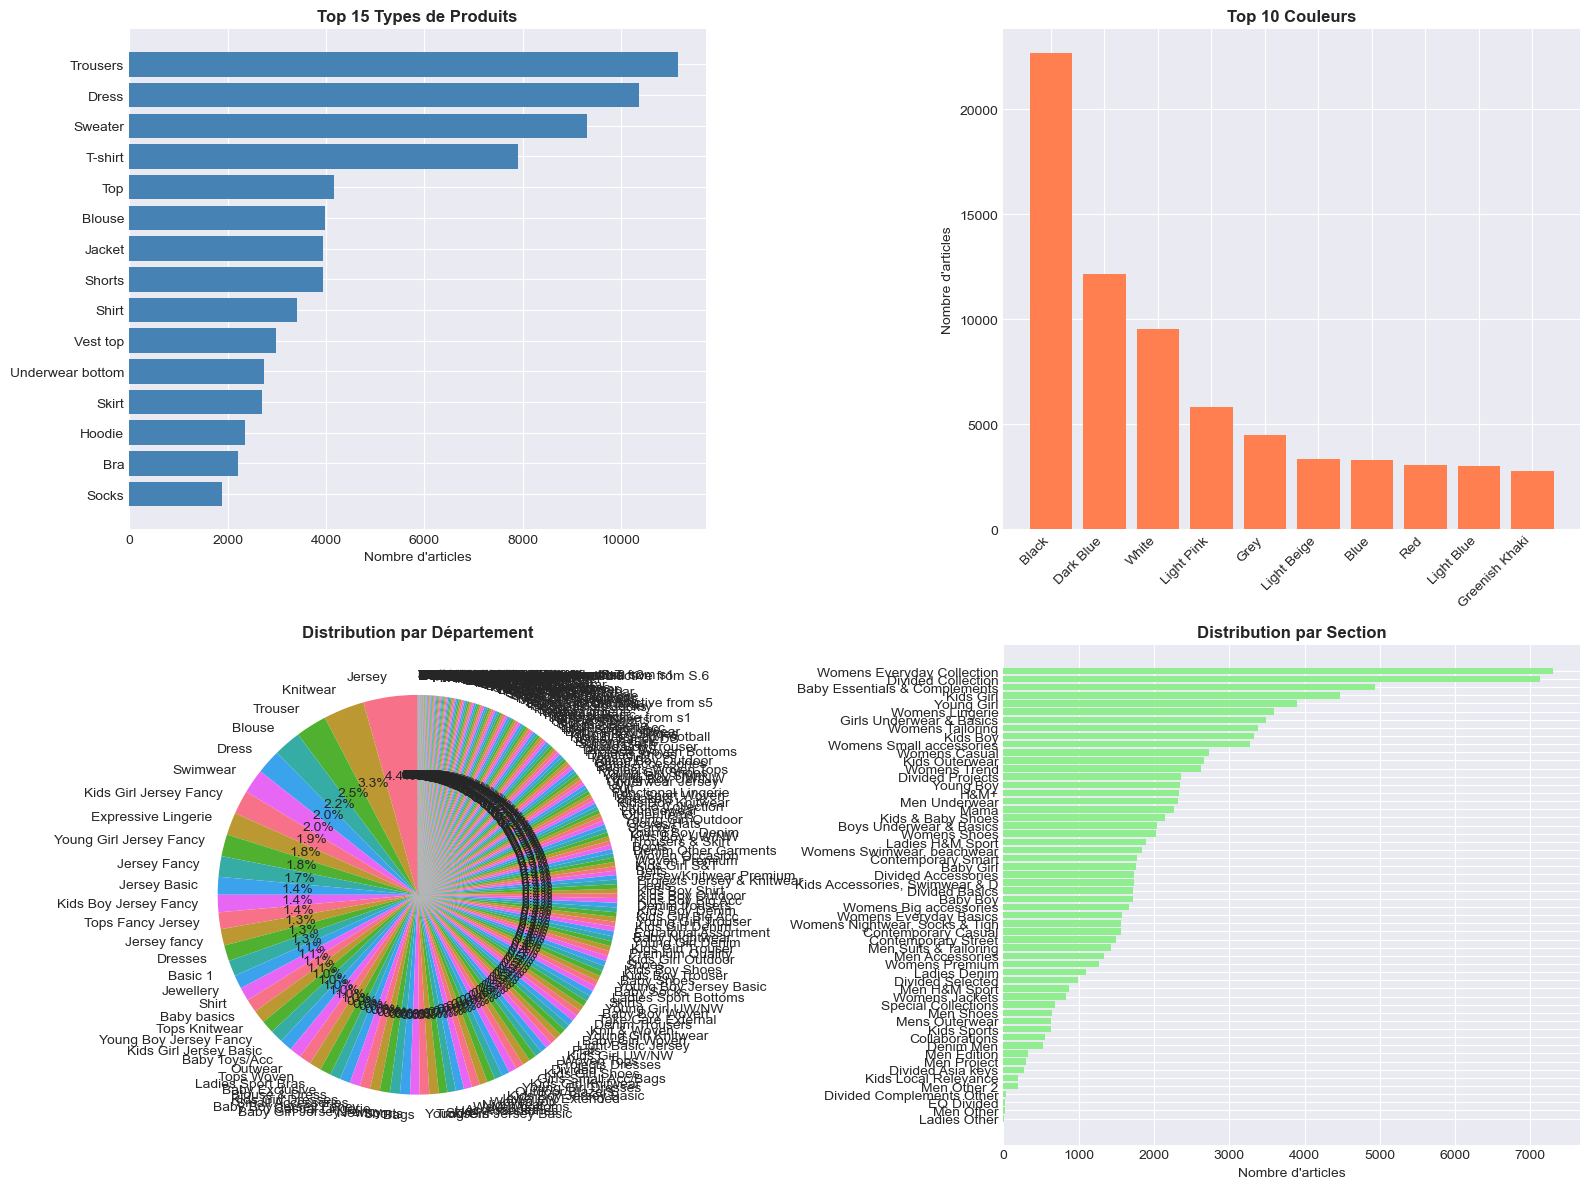

In [15]:
# Visualisations des métadonnées articles
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Product type
top_types = articles['product_type_name'].value_counts().head(15)
axes[0, 0].barh(range(len(top_types)), top_types.values, color='steelblue')
axes[0, 0].set_yticks(range(len(top_types)))
axes[0, 0].set_yticklabels(top_types.index)
axes[0, 0].set_xlabel('Nombre d\'articles')
axes[0, 0].set_title('Top 15 Types de Produits', fontweight='bold')
axes[0, 0].invert_yaxis()

# Colors
top_colors = articles['colour_group_name'].value_counts().head(10)
axes[0, 1].bar(range(len(top_colors)), top_colors.values, color='coral')
axes[0, 1].set_xticks(range(len(top_colors)))
axes[0, 1].set_xticklabels(top_colors.index, rotation=45, ha='right')
axes[0, 1].set_ylabel('Nombre d\'articles')
axes[0, 1].set_title('Top 10 Couleurs', fontweight='bold')

# Departments (pie chart)
dept_counts = articles['department_name'].value_counts()
axes[1, 0].pie(dept_counts.values, labels=dept_counts.index, autopct='%1.1f%%', startangle=90)
axes[1, 0].set_title('Distribution par Département', fontweight='bold')

# Sections
section_counts = articles['section_name'].value_counts()
axes[1, 1].barh(range(len(section_counts)), section_counts.values, color='lightgreen')
axes[1, 1].set_yticks(range(len(section_counts)))
axes[1, 1].set_yticklabels(section_counts.index)
axes[1, 1].set_xlabel('Nombre d\'articles')
axes[1, 1].set_title('Distribution par Section', fontweight='bold')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

### 8.2 Métadonnées des Clients

### 8.3 Analyse des Transactions par Métadonnées Articles

Pour mieux comprendre les préférences d'achat, nous allons analyser les transactions en fonction des différentes métadonnées des articles : product name, product type, product group, index group, et garment group.

In [16]:
# Fusionner transactions avec articles pour avoir accès aux métadonnées
print("🔗 Fusion des transactions avec les métadonnées articles...")
transactions_enriched = transactions.merge(
    articles[['article_id', 'prod_name', 'product_type_name', 'product_group_name', 
              'index_group_name', 'garment_group_name', 'colour_group_name', 'department_name']],
    on='article_id',
    how='left'
)

print(f"✅ Fusion terminée: {len(transactions_enriched):,} transactions enrichies")
print(f"📋 Nouvelles colonnes ajoutées: {list(set(transactions_enriched.columns) - set(transactions.columns))}")

# Vérifier s'il y a des articles sans métadonnées
missing_metadata = transactions_enriched[transactions_enriched['prod_name'].isnull()]
if len(missing_metadata) > 0:
    print(f"⚠️  {len(missing_metadata):,} transactions sans métadonnées article ({len(missing_metadata)/len(transactions_enriched)*100:.2f}%)")
else:
    print("✓ Toutes les transactions ont des métadonnées article")

🔗 Fusion des transactions avec les métadonnées articles...
✅ Fusion terminée: 31,788,324 transactions enrichies
📋 Nouvelles colonnes ajoutées: ['colour_group_name', 'garment_group_name', 'product_type_name', 'product_group_name', 'index_group_name', 'prod_name', 'department_name']
✓ Toutes les transactions ont des métadonnées article


#### 8.3.1 Transactions par Product Group Name

ANALYSE DES TRANSACTIONS PAR PRODUCT GROUP

📊 Top 10 Product Groups par nombre de transactions:

                    n_transactions  n_customers  total_revenue  pct_transactions  avg_price
product_group_name                                                                         
Garment Upper body        12552755      1092325  338981.789203         39.488571   0.027005
Garment Lower body         7046054       927480  231774.620034         22.165541   0.032894
Garment Full body          3552470       644925  128478.941678         11.175393   0.036166
Swimwear                   2579222       426146   57628.166508          8.113740   0.022343
Underwear                  2565858       517715   54395.857458          8.071700   0.021200
Accessories                1599593       491251   24893.822424          5.032014   0.015563
Shoes                       745521       269195   28888.356373          2.345267   0.038749
Socks & Tights              685712       267096    7811.136525          2.1

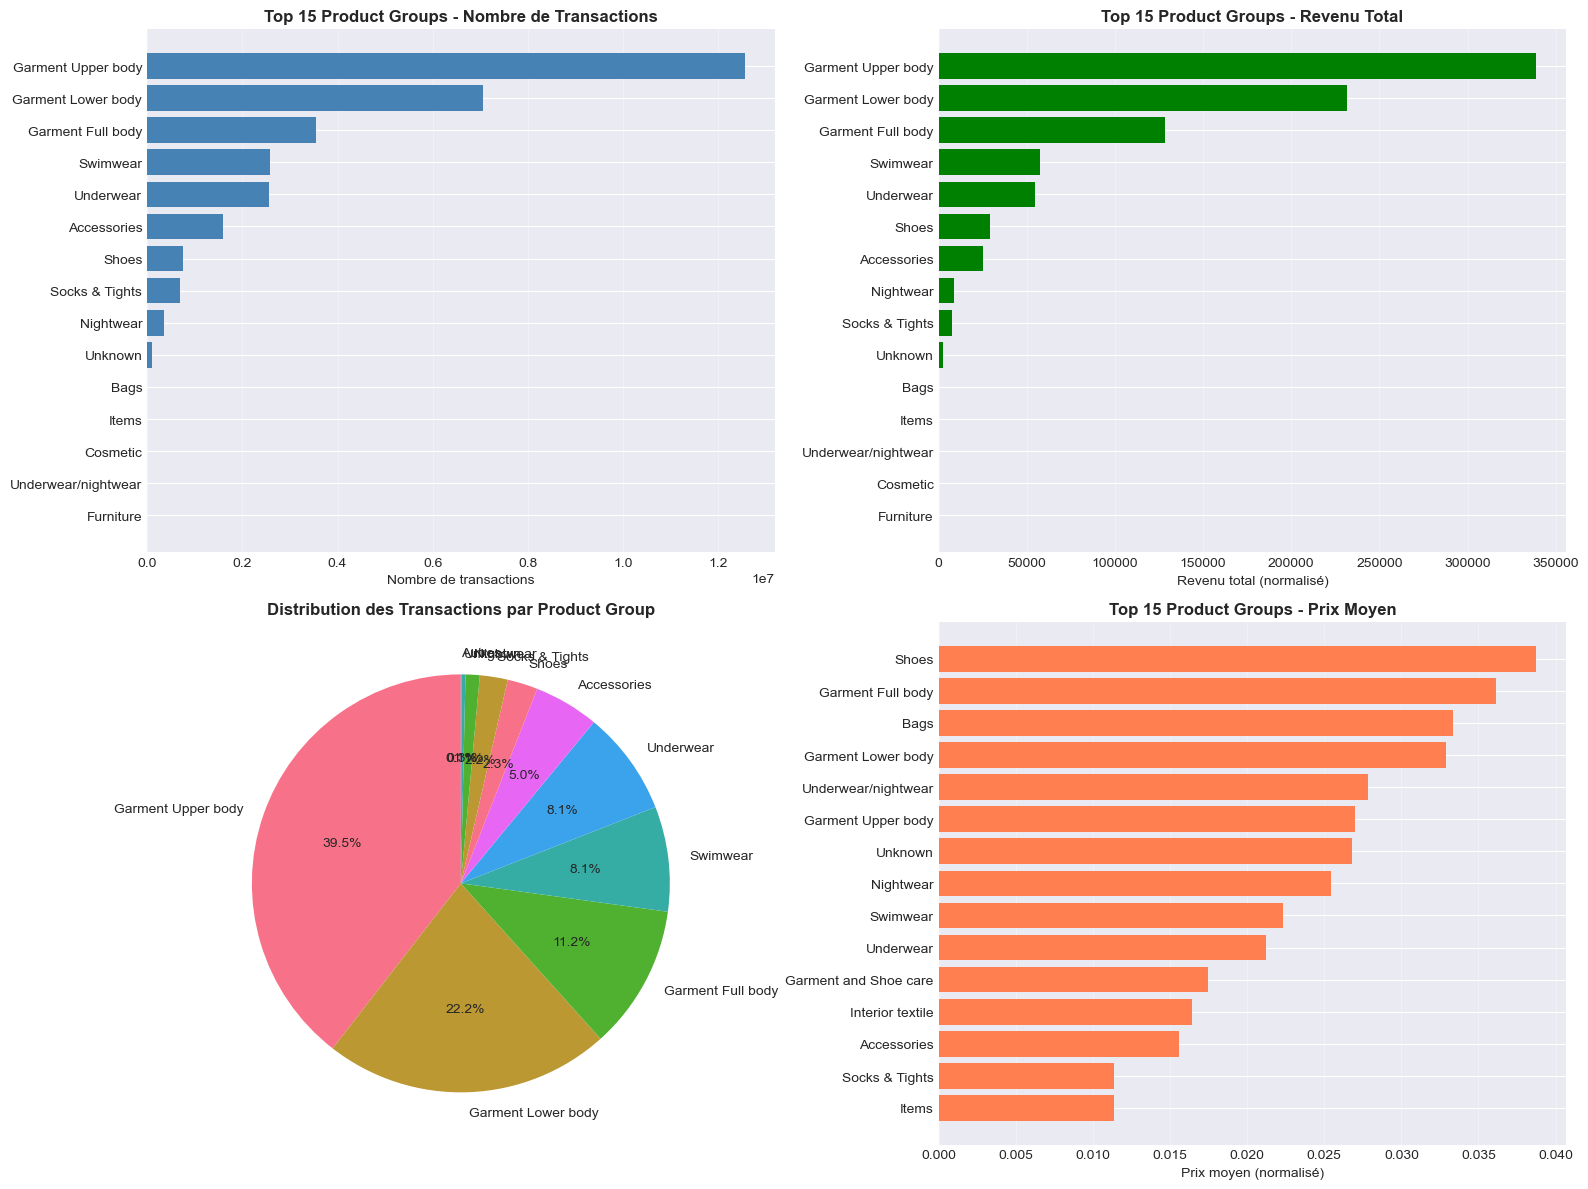


💡 Insights:
   • Le top 3 représente 72.8% des transactions
   • Product group le plus vendu: Garment Upper body
   • Product group le plus cher: Shoes


In [17]:
print("=" * 80)
print("ANALYSE DES TRANSACTIONS PAR PRODUCT GROUP")
print("=" * 80)

# Compter les transactions par product group
product_group_transactions = transactions_enriched.groupby('product_group_name').agg({
    'article_id': 'count',  # Nombre de transactions
    'customer_id': 'nunique',  # Nombre de clients uniques
    'price': 'sum'  # Revenu total
}).rename(columns={
    'article_id': 'n_transactions',
    'customer_id': 'n_customers',
    'price': 'total_revenue'
}).sort_values('n_transactions', ascending=False)

# Calculer les pourcentages
product_group_transactions['pct_transactions'] = (
    product_group_transactions['n_transactions'] / product_group_transactions['n_transactions'].sum() * 100
)
product_group_transactions['avg_price'] = (
    product_group_transactions['total_revenue'] / product_group_transactions['n_transactions']
)

print(f"\n📊 Top 10 Product Groups par nombre de transactions:\n")
print(product_group_transactions.head(10).to_string())

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Nombre de transactions par product group (top 15)
top_15 = product_group_transactions.head(15)
axes[0, 0].barh(range(len(top_15)), top_15['n_transactions'], color='steelblue')
axes[0, 0].set_yticks(range(len(top_15)))
axes[0, 0].set_yticklabels(top_15.index)
axes[0, 0].set_xlabel('Nombre de transactions')
axes[0, 0].set_title('Top 15 Product Groups - Nombre de Transactions', fontweight='bold')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(True, alpha=0.3, axis='x')

# 2. Revenu total par product group (top 15)
top_15_revenue = product_group_transactions.sort_values('total_revenue', ascending=False).head(15)
axes[0, 1].barh(range(len(top_15_revenue)), top_15_revenue['total_revenue'], color='green')
axes[0, 1].set_yticks(range(len(top_15_revenue)))
axes[0, 1].set_yticklabels(top_15_revenue.index)
axes[0, 1].set_xlabel('Revenu total (normalisé)')
axes[0, 1].set_title('Top 15 Product Groups - Revenu Total', fontweight='bold')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(True, alpha=0.3, axis='x')

# 3. Distribution en pourcentage (pie chart - top 10)
top_10_pct = product_group_transactions.head(10)
other_pct = 100 - top_10_pct['pct_transactions'].sum()
labels = list(top_10_pct.index) + ['Autres']
sizes = list(top_10_pct['pct_transactions']) + [other_pct]
axes[1, 0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
axes[1, 0].set_title('Distribution des Transactions par Product Group', fontweight='bold')

# 4. Prix moyen par product group (top 15)
top_15_price = product_group_transactions.sort_values('avg_price', ascending=False).head(15)
axes[1, 1].barh(range(len(top_15_price)), top_15_price['avg_price'], color='coral')
axes[1, 1].set_yticks(range(len(top_15_price)))
axes[1, 1].set_yticklabels(top_15_price.index)
axes[1, 1].set_xlabel('Prix moyen (normalisé)')
axes[1, 1].set_title('Top 15 Product Groups - Prix Moyen', fontweight='bold')
axes[1, 1].invert_yaxis()
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print(f"\n💡 Insights:")
print(f"   • Le top 3 représente {product_group_transactions.head(3)['pct_transactions'].sum():.1f}% des transactions")
print(f"   • Product group le plus vendu: {product_group_transactions.index[0]}")
print(f"   • Product group le plus cher: {product_group_transactions.sort_values('avg_price', ascending=False).index[0]}")

#### 8.3.2 Transactions par Product Type Name

ANALYSE DES TRANSACTIONS PAR PRODUCT TYPE

📊 Nombre de product types uniques: 130

🏆 Top 20 Product Types par nombre de transactions:

                   n_transactions  n_customers  total_revenue  pct_transactions  avg_price
product_type_name                                                                         
Trousers                  4217017       738844  150908.046237         13.265931   0.035785
Dress                     3238428       608936  118185.796576         10.187476   0.036495
Sweater                   2783274       642456   80732.982881          8.755649   0.029006
T-shirt                   2203750       558353   30274.877153          6.932577   0.013738
Top                       1583408       506862   32120.533831          4.981099   0.020286
Blouse                    1504868       441263   42424.630475          4.734028   0.028192
Vest top                  1414101       424945   22142.549288          4.448492   0.015658
Bra                       1335233       389371

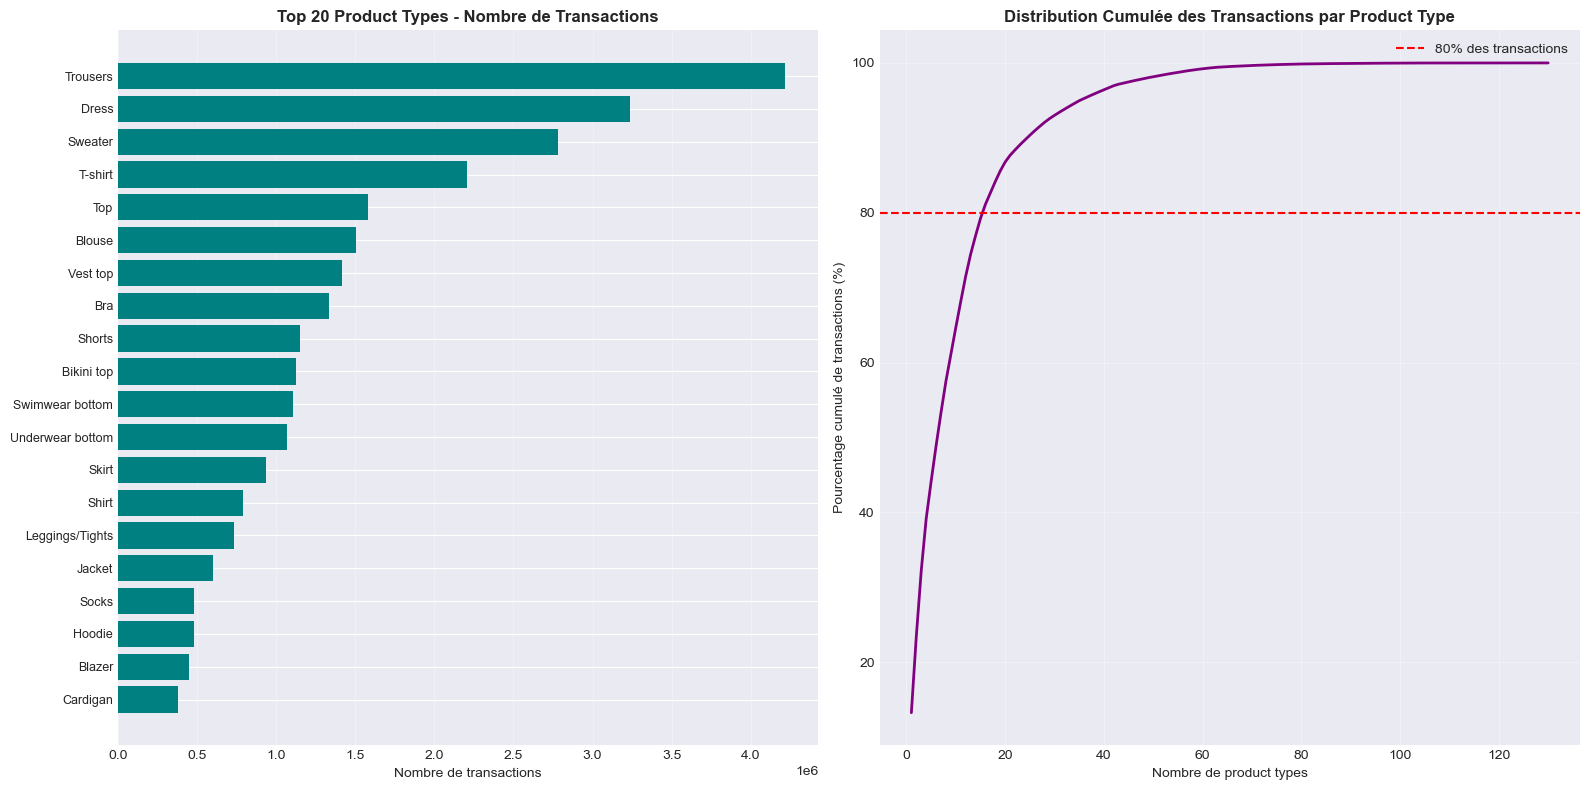


💡 Insights:
   • 16 product types (12.3%) génèrent 80% des transactions
   • Le top 5 représente 44.1% des transactions
   • Product type le plus vendu: Trousers (4,217,017.0 transactions)


In [18]:
print("=" * 80)
print("ANALYSE DES TRANSACTIONS PAR PRODUCT TYPE")
print("=" * 80)

# Compter les transactions par product type
product_type_transactions = transactions_enriched.groupby('product_type_name').agg({
    'article_id': 'count',
    'customer_id': 'nunique',
    'price': 'sum'
}).rename(columns={
    'article_id': 'n_transactions',
    'customer_id': 'n_customers',
    'price': 'total_revenue'
}).sort_values('n_transactions', ascending=False)

product_type_transactions['pct_transactions'] = (
    product_type_transactions['n_transactions'] / product_type_transactions['n_transactions'].sum() * 100
)
product_type_transactions['avg_price'] = (
    product_type_transactions['total_revenue'] / product_type_transactions['n_transactions']
)

print(f"\n📊 Nombre de product types uniques: {len(product_type_transactions)}")
print(f"\n🏆 Top 20 Product Types par nombre de transactions:\n")
print(product_type_transactions.head(20).to_string())

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 1. Top 20 product types
top_20 = product_type_transactions.head(20)
axes[0].barh(range(len(top_20)), top_20['n_transactions'], color='teal')
axes[0].set_yticks(range(len(top_20)))
axes[0].set_yticklabels(top_20.index, fontsize=9)
axes[0].set_xlabel('Nombre de transactions')
axes[0].set_title('Top 20 Product Types - Nombre de Transactions', fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

# 2. Distribution cumulée
cumsum_pct = product_type_transactions['pct_transactions'].cumsum()
axes[1].plot(range(1, len(cumsum_pct) + 1), cumsum_pct.values, linewidth=2, color='purple')
axes[1].axhline(y=80, color='red', linestyle='--', label='80% des transactions')
axes[1].set_xlabel('Nombre de product types')
axes[1].set_ylabel('Pourcentage cumulé de transactions (%)')
axes[1].set_title('Distribution Cumulée des Transactions par Product Type', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analyser la concentration
pct_80_idx = (cumsum_pct >= 80).idxmax()
n_types_80 = list(cumsum_pct.index).index(pct_80_idx) + 1
pct_types_80 = (n_types_80 / len(product_type_transactions)) * 100

print(f"\n💡 Insights:")
print(f"   • {n_types_80} product types ({pct_types_80:.1f}%) génèrent 80% des transactions")
print(f"   • Le top 5 représente {product_type_transactions.head(5)['pct_transactions'].sum():.1f}% des transactions")
print(f"   • Product type le plus vendu: {product_type_transactions.index[0]} ({product_type_transactions.iloc[0]['n_transactions']:,} transactions)")

#### 8.3.3 Transactions par Index Group Name

ANALYSE DES TRANSACTIONS PAR INDEX GROUP

📊 Nombre d'index groups: 5

📋 Distribution complète des transactions par Index Group:

                  n_transactions  n_customers  total_revenue  pct_transactions  avg_price
index_group_name                                                                         
Ladieswear              20415260      1199964  587272.173220         64.222511   0.028766
Divided                  7138254       878590  189270.043017         22.455585   0.026515
Menswear                 1771053       339126   48715.636831          5.571395   0.027507
Sport                    1246408       319308   35865.522610          3.920962   0.028775
Baby/Children            1217349       225761   23522.598373          3.829548   0.019323


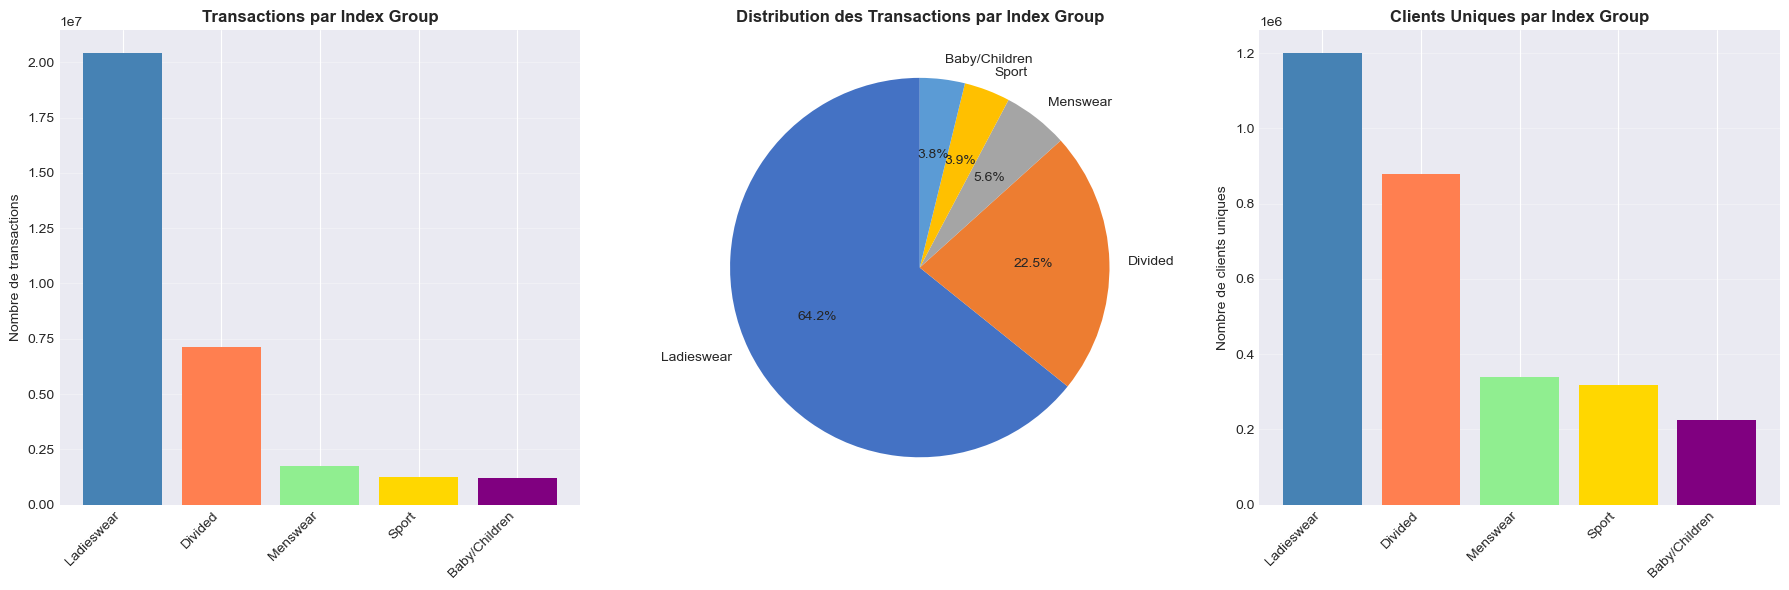


💡 Insights:
   • Ladieswear domine avec 64.2% des transactions
   • Revenu moyen le plus élevé: Sport
   • Le groupe avec le plus de clients: Ladieswear (1,199,964 clients)


In [19]:
print("=" * 80)
print("ANALYSE DES TRANSACTIONS PAR INDEX GROUP")
print("=" * 80)

# Compter les transactions par index group
index_group_transactions = transactions_enriched.groupby('index_group_name').agg({
    'article_id': 'count',
    'customer_id': 'nunique',
    'price': 'sum'
}).rename(columns={
    'article_id': 'n_transactions',
    'customer_id': 'n_customers',
    'price': 'total_revenue'
}).sort_values('n_transactions', ascending=False)

index_group_transactions['pct_transactions'] = (
    index_group_transactions['n_transactions'] / index_group_transactions['n_transactions'].sum() * 100
)
index_group_transactions['avg_price'] = (
    index_group_transactions['total_revenue'] / index_group_transactions['n_transactions']
)

print(f"\n📊 Nombre d'index groups: {len(index_group_transactions)}")
print(f"\n📋 Distribution complète des transactions par Index Group:\n")
print(index_group_transactions.to_string())

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Nombre de transactions
axes[0].bar(range(len(index_group_transactions)), index_group_transactions['n_transactions'], 
           color=['steelblue', 'coral', 'lightgreen', 'gold', 'purple'][:len(index_group_transactions)])
axes[0].set_xticks(range(len(index_group_transactions)))
axes[0].set_xticklabels(index_group_transactions.index, rotation=45, ha='right')
axes[0].set_ylabel('Nombre de transactions')
axes[0].set_title('Transactions par Index Group', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# 2. Pie chart - Distribution en pourcentage
colors_pie = ['#4472C4', '#ED7D31', '#A5A5A5', '#FFC000', '#5B9BD5']
axes[1].pie(index_group_transactions['n_transactions'], 
           labels=index_group_transactions.index,
           autopct='%1.1f%%', 
           colors=colors_pie[:len(index_group_transactions)],
           startangle=90)
axes[1].set_title('Distribution des Transactions par Index Group', fontweight='bold')

# 3. Nombre de clients uniques
axes[2].bar(range(len(index_group_transactions)), index_group_transactions['n_customers'],
           color=['steelblue', 'coral', 'lightgreen', 'gold', 'purple'][:len(index_group_transactions)])
axes[2].set_xticks(range(len(index_group_transactions)))
axes[2].set_xticklabels(index_group_transactions.index, rotation=45, ha='right')
axes[2].set_ylabel('Nombre de clients uniques')
axes[2].set_title('Clients Uniques par Index Group', fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n💡 Insights:")
print(f"   • {index_group_transactions.index[0]} domine avec {index_group_transactions.iloc[0]['pct_transactions']:.1f}% des transactions")
print(f"   • Revenu moyen le plus élevé: {index_group_transactions.sort_values('avg_price', ascending=False).index[0]}")
print(f"   • Le groupe avec le plus de clients: {index_group_transactions.sort_values('n_customers', ascending=False).index[0]} ({index_group_transactions['n_customers'].max():,} clients)")

#### 8.3.4 Transactions par Garment Group Name

ANALYSE DES TRANSACTIONS PAR GARMENT GROUP

📊 Nombre de garment groups: 21

🏆 Top 15 Garment Groups par nombre de transactions:

                    n_transactions  n_customers  total_revenue  pct_transactions  avg_price
garment_group_name                                                                         
Jersey Fancy               5171611       834125  122411.983373         16.268901   0.023670
Jersey Basic               3268451       659032   50749.003068         10.281923   0.015527
Under-, Nightwear          2966788       577482   63542.095339          9.332949   0.021418
Trousers                   2953711       639221  102068.225051          9.291811   0.034556
Swimwear                   2538085       422796   56249.933492          7.984331   0.022162
Blouses                    2510441       581614   71284.961373          7.897368   0.028395
Knitwear                   2392807       593284   77145.962508          7.527314   0.032241
Dresses Ladies             2147529       50

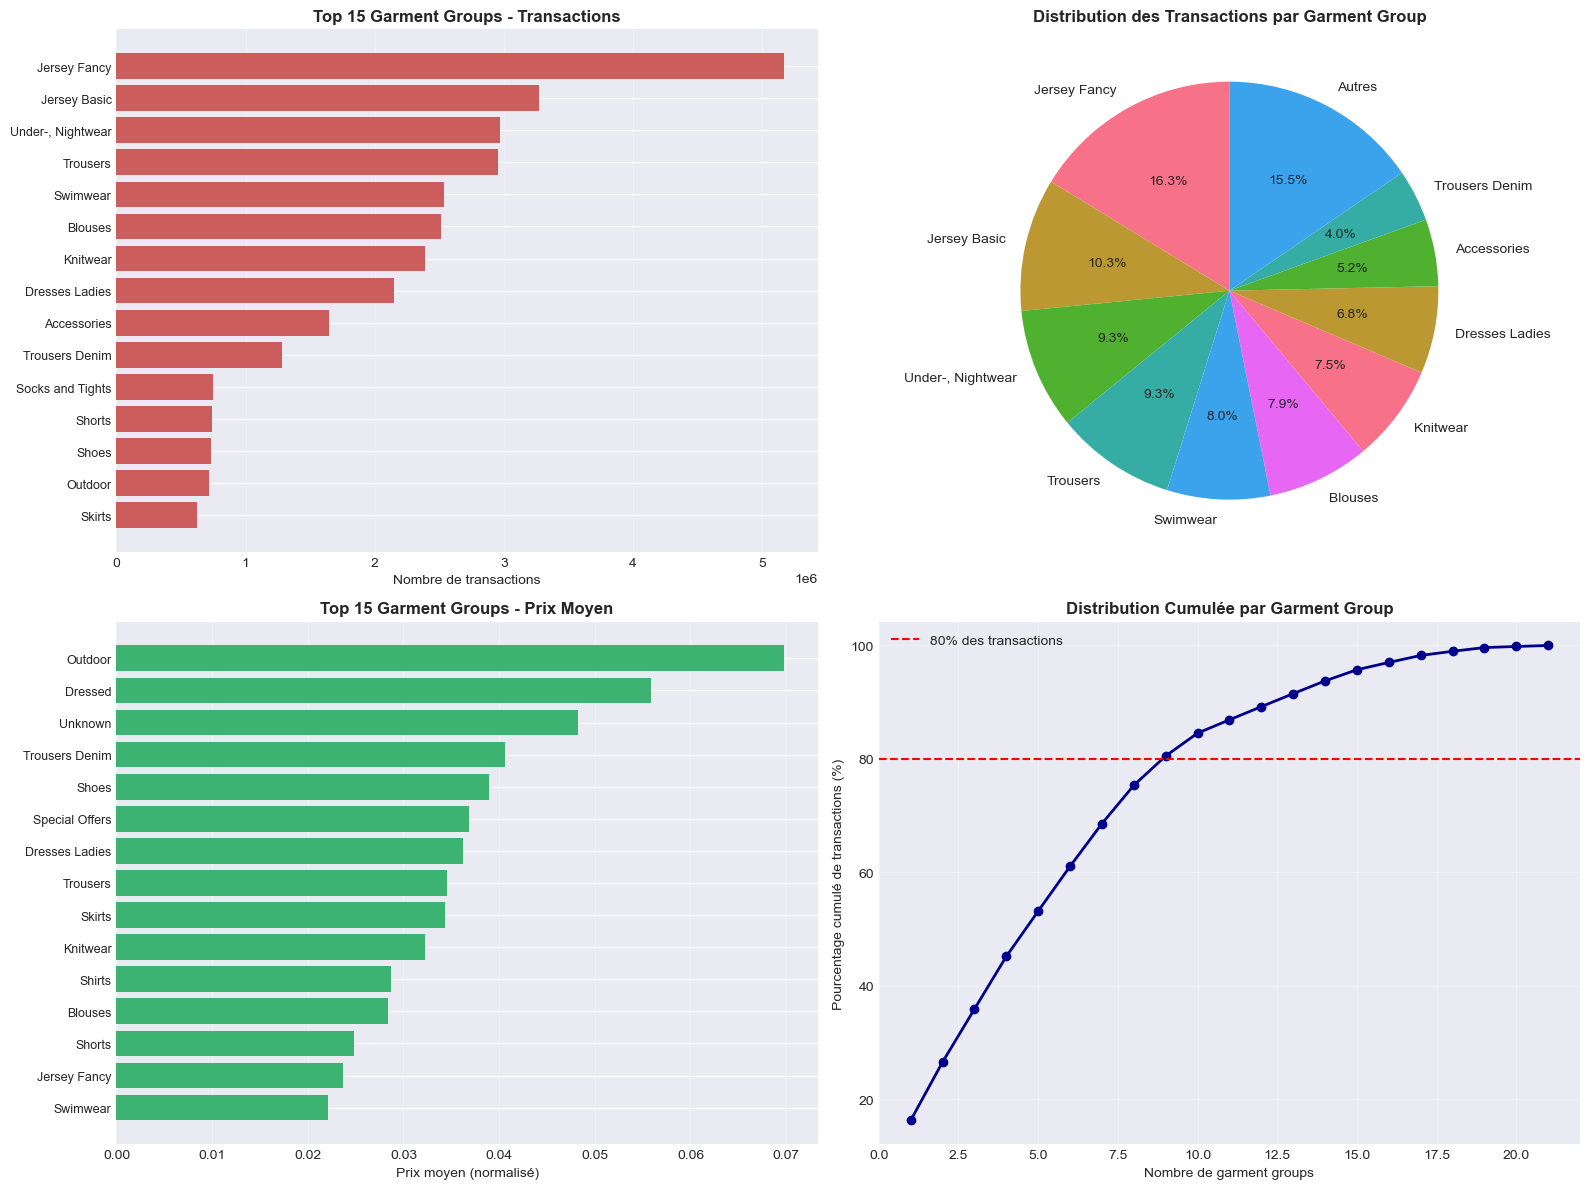


💡 Insights:
   • 9 garment groups (42.9%) génèrent 80% des transactions
   • Le top 3 représente 35.9% des transactions
   • Garment group le plus vendu: Jersey Fancy (5,171,611.0 transactions)
   • Garment group le plus cher: Outdoor


In [20]:
print("=" * 80)
print("ANALYSE DES TRANSACTIONS PAR GARMENT GROUP")
print("=" * 80)

# Compter les transactions par garment group
garment_group_transactions = transactions_enriched.groupby('garment_group_name').agg({
    'article_id': 'count',
    'customer_id': 'nunique',
    'price': 'sum'
}).rename(columns={
    'article_id': 'n_transactions',
    'customer_id': 'n_customers',
    'price': 'total_revenue'
}).sort_values('n_transactions', ascending=False)

garment_group_transactions['pct_transactions'] = (
    garment_group_transactions['n_transactions'] / garment_group_transactions['n_transactions'].sum() * 100
)
garment_group_transactions['avg_price'] = (
    garment_group_transactions['total_revenue'] / garment_group_transactions['n_transactions']
)

print(f"\n📊 Nombre de garment groups: {len(garment_group_transactions)}")
print(f"\n🏆 Top 15 Garment Groups par nombre de transactions:\n")
print(garment_group_transactions.head(15).to_string())

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top 15 garment groups par transactions
top_15 = garment_group_transactions.head(15)
axes[0, 0].barh(range(len(top_15)), top_15['n_transactions'], color='indianred')
axes[0, 0].set_yticks(range(len(top_15)))
axes[0, 0].set_yticklabels(top_15.index, fontsize=9)
axes[0, 0].set_xlabel('Nombre de transactions')
axes[0, 0].set_title('Top 15 Garment Groups - Transactions', fontweight='bold')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(True, alpha=0.3, axis='x')

# 2. Distribution en pourcentage (top 10 + autres)
top_10_pct = garment_group_transactions.head(10)
other_pct = 100 - top_10_pct['pct_transactions'].sum()
labels = list(top_10_pct.index) + ['Autres']
sizes = list(top_10_pct['pct_transactions']) + [other_pct]
axes[0, 1].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title('Distribution des Transactions par Garment Group', fontweight='bold')

# 3. Prix moyen par garment group (top 15)
top_15_price = garment_group_transactions.sort_values('avg_price', ascending=False).head(15)
axes[1, 0].barh(range(len(top_15_price)), top_15_price['avg_price'], color='mediumseagreen')
axes[1, 0].set_yticks(range(len(top_15_price)))
axes[1, 0].set_yticklabels(top_15_price.index, fontsize=9)
axes[1, 0].set_xlabel('Prix moyen (normalisé)')
axes[1, 0].set_title('Top 15 Garment Groups - Prix Moyen', fontweight='bold')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(True, alpha=0.3, axis='x')

# 4. Distribution cumulée
cumsum_pct = garment_group_transactions['pct_transactions'].cumsum()
axes[1, 1].plot(range(1, len(cumsum_pct) + 1), cumsum_pct.values, linewidth=2, color='darkblue', marker='o')
axes[1, 1].axhline(y=80, color='red', linestyle='--', label='80% des transactions')
axes[1, 1].set_xlabel('Nombre de garment groups')
axes[1, 1].set_ylabel('Pourcentage cumulé de transactions (%)')
axes[1, 1].set_title('Distribution Cumulée par Garment Group', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analyser la concentration
pct_80_idx = (cumsum_pct >= 80).idxmax()
n_garments_80 = list(cumsum_pct.index).index(pct_80_idx) + 1
pct_garments_80 = (n_garments_80 / len(garment_group_transactions)) * 100

print(f"\n💡 Insights:")
print(f"   • {n_garments_80} garment groups ({pct_garments_80:.1f}%) génèrent 80% des transactions")
print(f"   • Le top 3 représente {garment_group_transactions.head(3)['pct_transactions'].sum():.1f}% des transactions")
print(f"   • Garment group le plus vendu: {garment_group_transactions.index[0]} ({garment_group_transactions.iloc[0]['n_transactions']:,} transactions)")
print(f"   • Garment group le plus cher: {garment_group_transactions.sort_values('avg_price', ascending=False).index[0]}")

#### 8.3.5 Transactions par Product Name (Top Produits)

ANALYSE DES TRANSACTIONS PAR NOM DE PRODUIT

📊 Nombre de noms de produits uniques: 45,508

🏆 Top 30 Produits par nombre de transactions:

                  prod_name  n_transactions  n_variants  n_customers  total_revenue  pct_transactions  avg_price
   Jade HW Skinny Denim TRS          168052          19        77452    5398.928237          0.528660   0.032127
             Luna skinny RW          143216          34        76414    4178.059525          0.450530   0.029173
     Timeless Midrise Brief          122143          30        71886    1906.257949          0.384239   0.015607
                  Tilly (1)          105670          29        60746     852.298458          0.332418   0.008066
                   Cat Tee.           81304          28        51397     656.533898          0.255767   0.008075
Simple as That Triangle Top           74827          17        49080    1794.061712          0.235391   0.023976
     Shake it in Balconette           74574          31        43611   

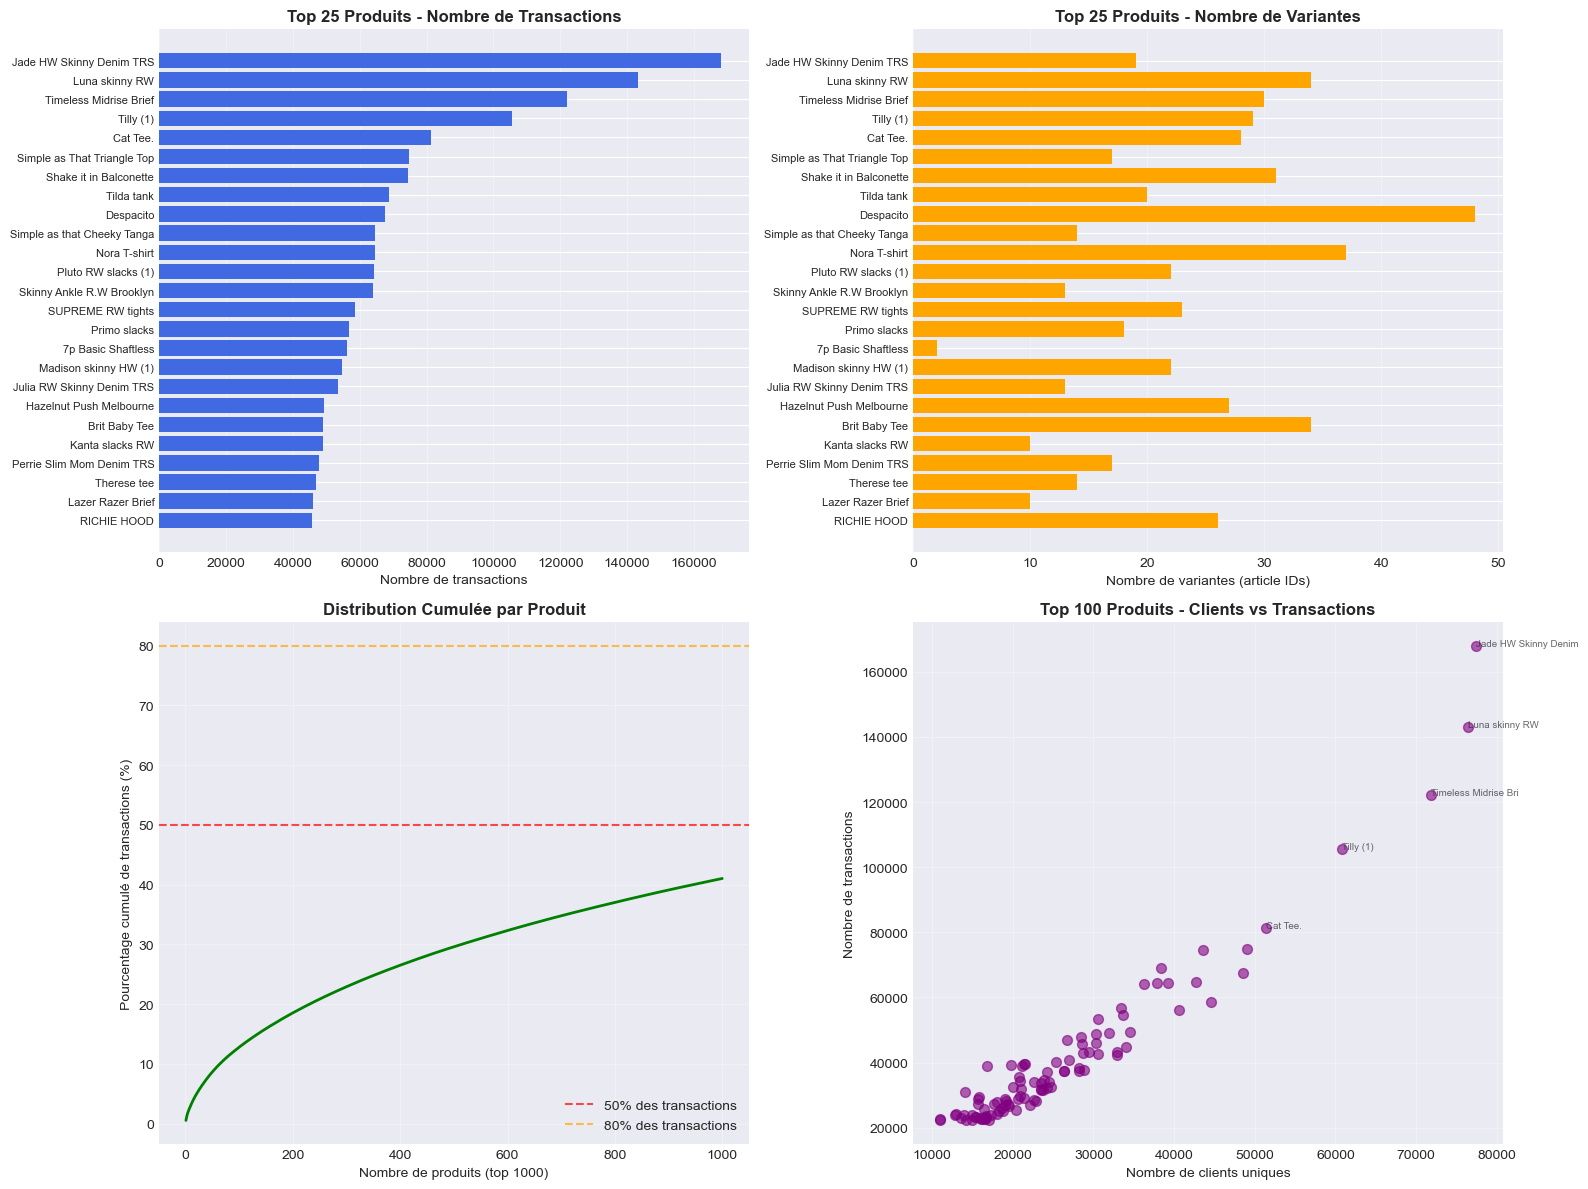


💡 Insights:
   • 1,591 produits (3.50%) génèrent 50% des transactions
   • 6,684 produits (14.69%) génèrent 80% des transactions
   • Produit le plus vendu: 'Jade HW Skinny Denim TRS' (168,052 transactions)
   • Ce produit a 19 variantes (couleurs, tailles, etc.)
   • Le top 10 représente 3.1% des transactions


In [21]:
print("=" * 80)
print("ANALYSE DES TRANSACTIONS PAR NOM DE PRODUIT")
print("=" * 80)

# Compter les transactions par product name
product_name_transactions = transactions_enriched.groupby('prod_name').agg({
    'article_id': ['count', 'nunique'],  # Count transactions + unique article IDs
    'customer_id': 'nunique',
    'price': 'sum'
}).reset_index()

# Flatten column names
product_name_transactions.columns = ['prod_name', 'n_transactions', 'n_variants', 'n_customers', 'total_revenue']
product_name_transactions = product_name_transactions.sort_values('n_transactions', ascending=False)

product_name_transactions['pct_transactions'] = (
    product_name_transactions['n_transactions'] / product_name_transactions['n_transactions'].sum() * 100
)
product_name_transactions['avg_price'] = (
    product_name_transactions['total_revenue'] / product_name_transactions['n_transactions']
)

print(f"\n📊 Nombre de noms de produits uniques: {len(product_name_transactions):,}")
print(f"\n🏆 Top 30 Produits par nombre de transactions:\n")
print(product_name_transactions.head(30).to_string(index=False))

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top 25 produits
top_25 = product_name_transactions.head(25)
axes[0, 0].barh(range(len(top_25)), top_25['n_transactions'], color='royalblue')
axes[0, 0].set_yticks(range(len(top_25)))
axes[0, 0].set_yticklabels(top_25['prod_name'], fontsize=8)
axes[0, 0].set_xlabel('Nombre de transactions')
axes[0, 0].set_title('Top 25 Produits - Nombre de Transactions', fontweight='bold')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(True, alpha=0.3, axis='x')

# 2. Nombre de variantes par produit (top 25)
axes[0, 1].barh(range(len(top_25)), top_25['n_variants'], color='orange')
axes[0, 1].set_yticks(range(len(top_25)))
axes[0, 1].set_yticklabels(top_25['prod_name'], fontsize=8)
axes[0, 1].set_xlabel('Nombre de variantes (article IDs)')
axes[0, 1].set_title('Top 25 Produits - Nombre de Variantes', fontweight='bold')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(True, alpha=0.3, axis='x')

# 3. Distribution cumulée
cumsum_pct = product_name_transactions['pct_transactions'].cumsum()
axes[1, 0].plot(range(1, min(1001, len(cumsum_pct) + 1)), cumsum_pct.head(1000).values, 
               linewidth=2, color='green')
axes[1, 0].axhline(y=50, color='red', linestyle='--', label='50% des transactions', alpha=0.7)
axes[1, 0].axhline(y=80, color='orange', linestyle='--', label='80% des transactions', alpha=0.7)
axes[1, 0].set_xlabel('Nombre de produits (top 1000)')
axes[1, 0].set_ylabel('Pourcentage cumulé de transactions (%)')
axes[1, 0].set_title('Distribution Cumulée par Produit', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Nuage de points : Transactions vs Nombre de clients
top_100 = product_name_transactions.head(100)
axes[1, 1].scatter(top_100['n_customers'], top_100['n_transactions'], 
                  alpha=0.6, s=50, color='purple')
axes[1, 1].set_xlabel('Nombre de clients uniques')
axes[1, 1].set_ylabel('Nombre de transactions')
axes[1, 1].set_title('Top 100 Produits - Clients vs Transactions', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

# Annoter quelques points
for i, row in top_100.head(5).iterrows():
    axes[1, 1].annotate(row['prod_name'][:20], 
                       (row['n_customers'], row['n_transactions']),
                       fontsize=7, alpha=0.7)

plt.tight_layout()
plt.show()

# Analyser la concentration
pct_50_idx = (cumsum_pct >= 50).idxmax() if any(cumsum_pct >= 50) else len(cumsum_pct) - 1
pct_80_idx = (cumsum_pct >= 80).idxmax() if any(cumsum_pct >= 80) else len(cumsum_pct) - 1
n_products_50 = list(cumsum_pct.index).index(pct_50_idx) + 1
n_products_80 = list(cumsum_pct.index).index(pct_80_idx) + 1

print(f"\n💡 Insights:")
print(f"   • {n_products_50:,} produits ({n_products_50/len(product_name_transactions)*100:.2f}%) génèrent 50% des transactions")
print(f"   • {n_products_80:,} produits ({n_products_80/len(product_name_transactions)*100:.2f}%) génèrent 80% des transactions")
print(f"   • Produit le plus vendu: '{product_name_transactions.iloc[0]['prod_name']}' ({product_name_transactions.iloc[0]['n_transactions']:,} transactions)")
print(f"   • Ce produit a {int(product_name_transactions.iloc[0]['n_variants'])} variantes (couleurs, tailles, etc.)")
print(f"   • Le top 10 représente {product_name_transactions.head(10)['pct_transactions'].sum():.1f}% des transactions")

#### 8.3.6 Synthèse des Analyses par Métadonnées

Cette analyse approfondie des transactions par métadonnées articles nous permet de tirer plusieurs conclusions importantes :

**🎯 Features Clés pour le Content-Based Filtering :**
1. **Index Group Name** (5 catégories) - Très discriminant, domine Ladieswear
2. **Product Group Name** (19 catégories) - Bon équilibre entre granularité et généralisation
3. **Garment Group Name** (21 catégories) - Features détaillées pour similarité fine
4. **Product Type Name** (132 types) - Très granulaire mais risque de sur-spécialisation

**📊 Patterns Observés :**
- **Concentration élevée** : Les top produits/catégories dominent largement les ventes
- **Longue traîne** : Beaucoup de produits peu vendus → besoin de modèles hybrides
- **Variantes produits** : Un même nom de produit peut avoir multiples article_ids (couleurs, tailles)

**💡 Implications pour le Système de Recommandation :**

1. **Pour le Content-Based Filtering :**
   - Utiliser `product_group_name`, `index_group_name`, `garment_group_name` comme features principales
   - Ajouter `colour_group_name` pour diversifier les recommandations
   - Encodage One-Hot → ~45 features binaires

2. **Pour le Collaborative Filtering :**
   - Privilégier les articles avec minimum d'achats (ex: 10+) pour éviter le bruit
   - Segmenter par `index_group_name` pour des recommandations plus pertinentes

3. **Pour le Modèle Hybride (LightFM) :**
   - Combiner interactions binaires + item features (product_group, garment_group, index_group)
   - Permet de recommander nouveaux articles grâce aux métadonnées

**🔧 Prochaines Étapes :**
- Échantillonnage intelligent basé sur ces insights
- Filtrage des articles peu populaires tout en préservant la diversité
- Création de la matrice de features pour Content-Based Filtering

EXPLORATION DES MÉTADONNÉES - CLIENTS

📋 Colonnes disponibles (7):
   • customer_id
   • FN
   • Active
   • club_member_status
   • fashion_news_frequency
   • age
   • postal_code

📊 Distribution de l'âge:
count    1.356119e+06
mean     3.638696e+01
std      1.431363e+01
min      1.600000e+01
25%      2.400000e+01
50%      3.200000e+01
75%      4.900000e+01
max      9.900000e+01
Name: age, dtype: float64


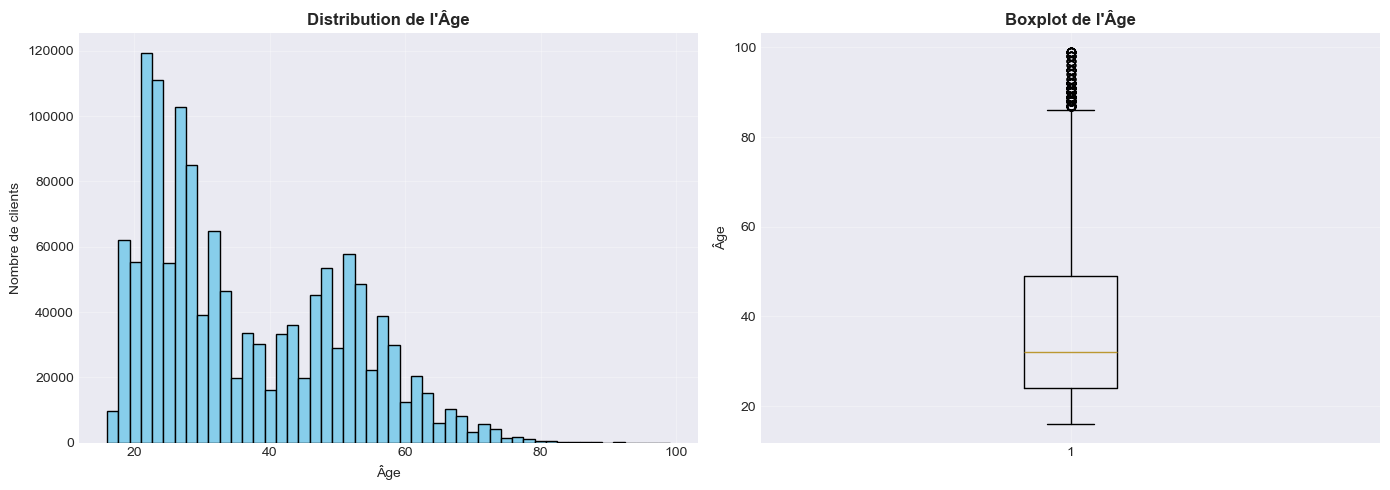


📈 Distribution de club_member_status:
   ACTIVE                        : 1,272,491 (92.7%)
   PRE-CREATE                    : 92,960 (6.8%)
   LEFT CLUB                     : 467 (0.0%)

📈 Distribution de fashion_news_frequency:
   NONE                          : 877,711 (64.0%)
   Regularly                     : 477,416 (34.8%)
   Monthly                       : 842 (0.1%)

📈 Distribution de postal_code:
   2c29ae653a9282cce4151bd87643c907644e09541abc28ae87dea0d1f6603b1c: 120,303 (8.8%)
   cc4ed85e30f4977dae47662ddc468cd2eec11472de6fac5ec985080fd92243c8: 261 (0.0%)
   714976379549eb90aae4a71bca6c7402cc646ae7c40f6c1cb91d4b5a18623fc1: 159 (0.0%)
   7c1fa3b0ec1d37ce2c3f34f63bd792f3b4494f324b6be5d1e4ba6a75456b96a7: 157 (0.0%)
   5b7eb31eabebd3277de632b82267286d847fd5d44287ee150bb4206b48439145: 156 (0.0%)
   1f5bd429acc88fbbf24de844a59e438704aa8761bc7b99fd977cad297c50b74c: 154 (0.0%)
   9d5787501bf1c77592156ba51eab13f4a2670c807686431a9e22a69090b02358: 141 (0.0%)
   a1959a16bf167858c93a66e

In [22]:
print("=" * 80)
print("EXPLORATION DES MÉTADONNÉES - CLIENTS")
print("=" * 80)

print(f"\n📋 Colonnes disponibles ({len(customers.columns)}):")
for col in customers.columns:
    print(f"   • {col}")

# Analyser les features disponibles
if 'age' in customers.columns:
    print(f"\n📊 Distribution de l'âge:")
    print(customers['age'].describe())
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogramme
    axes[0].hist(customers['age'].dropna(), bins=50, color='skyblue', edgecolor='black')
    axes[0].set_xlabel('Âge')
    axes[0].set_ylabel('Nombre de clients')
    axes[0].set_title('Distribution de l\'Âge', fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # Boxplot
    axes[1].boxplot(customers['age'].dropna())
    axes[1].set_ylabel('Âge')
    axes[1].set_title('Boxplot de l\'Âge', fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Autres features catégorielles
for col in customers.columns:
    if customers[col].dtype == 'object' and col != 'customer_id':
        print(f"\n📈 Distribution de {col}:")
        value_counts = customers[col].value_counts()
        for val, count in value_counts.head(10).items():
            pct = count / len(customers) * 100
            print(f"   {val:30s}: {count:,} ({pct:.1f}%)")

## 9. Synthèse et Conclusions

### Points Clés à Retenir

In [23]:
print("="*80)
print("SYNTHÈSE DE L'EXPLORATION DES DONNÉES")
print("="*80)

print("\n📊 DIMENSIONS DU DATASET:")
print(f"   • Utilisateurs uniques: {n_users:,}")
print(f"   • Articles uniques: {n_items:,}")
print(f"   • Interactions totales: {n_interactions:,}")
print(f"   • Sparsité: {sparsity:.2%}")

print("\n📈 DISTRIBUTIONS:")
print(f"   • Interactions moyennes par user: {user_interactions.mean():.2f}")
print(f"   • Interactions moyennes par item: {item_interactions.mean():.2f}")
print(f"   • Effet longue traîne très prononcé (règle 80/20 vérifiée)")

print("\n⏱️ TEMPORALITÉ:")
print(f"   • Période: {min_date.strftime('%Y-%m-%d')} → {max_date.strftime('%Y-%m-%d')}")
print(f"   • Patterns saisonniers présents")
print(f"   • Variations hebdomadaires observées")

print("\n🎯 IMPLICATIONS POUR LE SYSTÈME DE RECOMMANDATION:")
print("   \n   1. SPARSITÉ ÉLEVÉE:")
print("      → Besoin de techniques adaptées (Matrix Factorization)")
print("      → Cold-start sera un défi majeur")

print("   \n   2. EFFET LONGUE TRAÎNE:")
print("      → Beaucoup d'items peu populaires")
print("      → Modèles hybrides recommandés pour diversité")
print("      → Content-based filtering utile pour items rares")

print("   \n   3. MÉTADONNÉES RICHES:")
print("      → Features items disponibles (couleur, type, département)")
print("      → Features users disponibles (âge, etc.)")
print("      → Opportunité pour modèles hybrides avec LightFM")

print("   \n   4. DIMENSION TEMPORELLE:")
print("      → Utiliser split temporel pour validation réaliste")
print("      → Possibilité d'incorporer features temporelles")
print("      → Patterns saisonniers exploitables")

print("   \n   5. STRATÉGIE D'ÉCHANTILLONNAGE:")
print("      → Dataset très large → échantillonnage nécessaire")
print("      → Privilégier users/items avec activité minimale")
print("      → Préserver les distributions lors du sampling")

print("\n" + "="*80)
print("✅ EXPLORATION TERMINÉE - PRÊT POUR L'ÉTAPE 2 (SAMPLING)")
print("="*80)

SYNTHÈSE DE L'EXPLORATION DES DONNÉES

📊 DIMENSIONS DU DATASET:
   • Utilisateurs uniques: 1,362,281
   • Articles uniques: 104,547
   • Interactions totales: 31,788,324
   • Sparsité: 99.98%

📈 DISTRIBUTIONS:
   • Interactions moyennes par user: 23.33
   • Interactions moyennes par item: 304.06
   • Effet longue traîne très prononcé (règle 80/20 vérifiée)

⏱️ TEMPORALITÉ:
   • Période: 2018-09-20 → 2020-09-22
   • Patterns saisonniers présents
   • Variations hebdomadaires observées

🎯 IMPLICATIONS POUR LE SYSTÈME DE RECOMMANDATION:
   
   1. SPARSITÉ ÉLEVÉE:
      → Besoin de techniques adaptées (Matrix Factorization)
      → Cold-start sera un défi majeur
   
   2. EFFET LONGUE TRAÎNE:
      → Beaucoup d'items peu populaires
      → Modèles hybrides recommandés pour diversité
      → Content-based filtering utile pour items rares
   
   3. MÉTADONNÉES RICHES:
      → Features items disponibles (couleur, type, département)
      → Features users disponibles (âge, etc.)
      → Opport



**Prochaine étape** : `step2-DataSampling.ipynb`